# Phần 2: Trực quan hóa & Phân tích dữ liệu

### Mục lục
| STT | Chủ đề |
|-----|--------|
| 1   | Tổng quan Doanh thu & Lợi nhuận |
| 2   | Tính mùa vụ & Xu hướng |
| 3   | Phân tích Khách hàng & Phân khúc |
| 4   | Hiệu quả Khuyến mãi |
| 5   | Trả hàng & Chất lượng dịch vụ |
| 6   | Kênh bán hàng & Web Traffic |
| 7   | Tồn kho & Chuỗi cung ứng |
| 8   | Phân tích Địa lý |
| 9   | Tổng hợp & Đề xuất chiến lược |

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'success': '#2CA58D', 'danger': '#E63946', 'dark': '#1D3557', 'light': '#A8DADC',
    'purple': '#7B2D8E', 'teal': '#17A2B8', 'gold': '#FFC107'
}
PAL = list(COLORS.values())

def fmt_vnd(x, pos=None):
    if abs(x) >= 1e9: return f'{x/1e9:.1f}B'
    elif abs(x) >= 1e6: return f'{x/1e6:.1f}M'
    elif abs(x) >= 1e3: return f'{x/1e3:.0f}K'
    return f'{x:.0f}'

In [2]:
# Load all datasets
sales      = pd.read_csv('data/sales.csv', parse_dates=['Date'])
orders     = pd.read_csv('data/orders.csv', parse_dates=['order_date'])
order_items= pd.read_csv('data/order_items.csv')
products   = pd.read_csv('data/products.csv')
customers  = pd.read_csv('data/customers.csv', parse_dates=['signup_date'])
payments   = pd.read_csv('data/payments.csv')
shipments  = pd.read_csv('data/shipments.csv', parse_dates=['ship_date', 'delivery_date'])
returns    = pd.read_csv('data/returns.csv', parse_dates=['return_date'])
reviews    = pd.read_csv('data/reviews.csv', parse_dates=['review_date'])
promotions = pd.read_csv('data/promotions.csv', parse_dates=['start_date', 'end_date'])
geography  = pd.read_csv('data/geography.csv')
inventory  = pd.read_csv('data/inventory.csv', parse_dates=['snapshot_date'])
web_traffic= pd.read_csv('data/web_traffic.csv', parse_dates=['date'])

print('=== Dataset Shapes ===')
for name, df in [('sales', sales), ('orders', orders), ('order_items', order_items),
                  ('products', products), ('customers', customers), ('payments', payments),
                  ('shipments', shipments), ('returns', returns), ('reviews', reviews),
                  ('promotions', promotions), ('geography', geography), ('inventory', inventory),
                  ('web_traffic', web_traffic)]:
    print(f'  {name:15s}: {df.shape[0]:>8,} rows × {df.shape[1]:>2} cols')

=== Dataset Shapes ===
  sales          :    3,833 rows ×  3 cols
  orders         :  646,945 rows ×  8 cols
  order_items    :  714,669 rows ×  7 cols
  products       :    2,412 rows ×  8 cols
  customers      :  121,930 rows ×  7 cols
  payments       :  646,945 rows ×  4 cols
  shipments      :  566,067 rows ×  4 cols
  returns        :   39,939 rows ×  7 cols
  reviews        :  113,551 rows ×  7 cols
  promotions     :       50 rows × 10 cols
  geography      :   39,948 rows ×  4 cols
  inventory      :   60,247 rows × 17 cols
  web_traffic    :    3,652 rows ×  7 cols


## 1. Tổng quan Doanh thu & Lợi nhuận

> **Câu hỏi:** Doanh thu và chi phí đã thay đổi như thế nào qua 10 năm? Biên lợi nhuận gộp có ổn định không? Tại sao lại có sự suy giảm trong giai đoạn 2017-2021

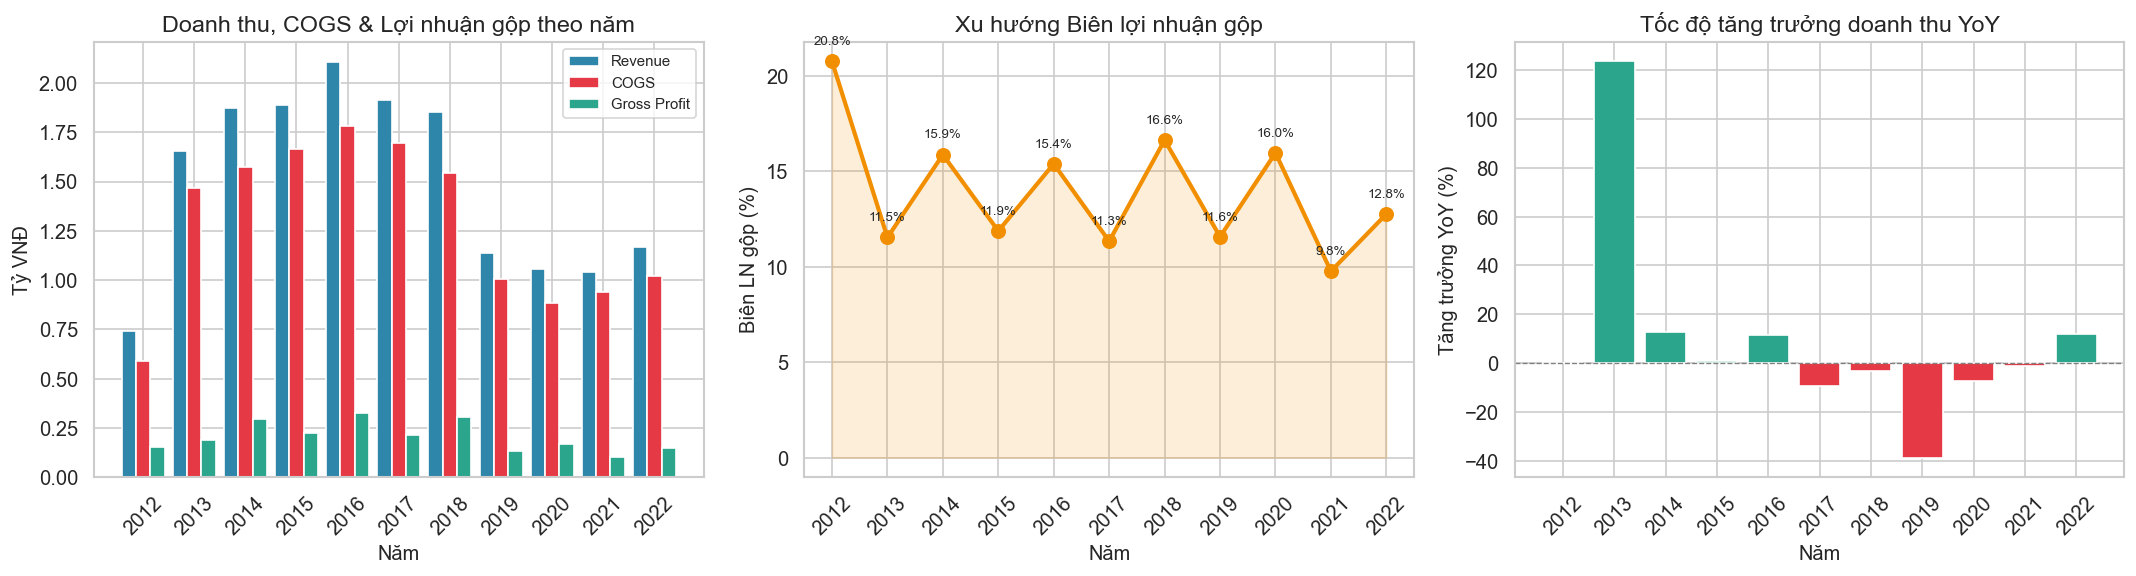


📊 TÓM TẮT 10+ NĂM HOẠT ĐỘNG
  Tổng doanh thu tích lũy : 16.4 tỷ VNĐ
  Tổng lợi nhuận gộp      : 2.3 tỷ VNĐ
  Biên LN gộp trung bình  : 14.0%
  Tăng trưởng DT TB/năm   : 10.2%
  Năm DT cao nhất         : 2016
  Năm tăng trưởng mạnh nhất: 2013 (123.5%)


In [3]:
# === Tính các chỉ số theo năm ===
sales['year'] = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month
sales['Gross_Profit'] = sales['Revenue'] - sales['COGS']
sales['Margin_pct'] = sales['Gross_Profit'] / sales['Revenue'] * 100

annual = sales.groupby('year').agg(
    Revenue=('Revenue', 'sum'),
    COGS=('COGS', 'sum'),
    Gross_Profit=('Gross_Profit', 'sum'),
    Days=('Date', 'count')
).reset_index()
annual['Margin_pct'] = annual['Gross_Profit'] / annual['Revenue'] * 100
annual['Rev_YoY'] = annual['Revenue'].pct_change() * 100
annual['Rev_per_day'] = annual['Revenue'] / annual['Days']

# --- Chart 1: Revenue, COGS, Gross Profit by Year ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart
x = annual['year']
w = 0.28
axes[0].bar(x - w, annual['Revenue']/1e9, w, label='Revenue', color=COLORS['primary'])
axes[0].bar(x, annual['COGS']/1e9, w, label='COGS', color=COLORS['danger'])
axes[0].bar(x + w, annual['Gross_Profit']/1e9, w, label='Gross Profit', color=COLORS['success'])
axes[0].set_xlabel('Năm')
axes[0].set_ylabel('Tỷ VNĐ')
axes[0].set_title('Doanh thu, COGS & Lợi nhuận gộp theo năm')
axes[0].legend(fontsize=9)
axes[0].set_xticks(x)
axes[0].tick_params(axis='x', rotation=45)

# Margin % trend
axes[1].plot(annual['year'], annual['Margin_pct'], 'o-', color=COLORS['accent'], linewidth=2.5, markersize=8)
axes[1].fill_between(annual['year'], annual['Margin_pct'], alpha=0.15, color=COLORS['accent'])
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('Biên LN gộp (%)')
axes[1].set_title('Xu hướng Biên lợi nhuận gộp')
axes[1].set_xticks(x)
axes[1].tick_params(axis='x', rotation=45)
for _, row in annual.iterrows():
    axes[1].annotate(f"{row['Margin_pct']:.1f}%", (row['year'], row['Margin_pct']),
                     textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8)

# YoY Growth
colors_yoy = [COLORS['success'] if v >= 0 else COLORS['danger'] for v in annual['Rev_YoY'].fillna(0)]
axes[2].bar(annual['year'], annual['Rev_YoY'].fillna(0), color=colors_yoy)
axes[2].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_xlabel('Năm')
axes[2].set_ylabel('Tăng trưởng YoY (%)')
axes[2].set_title('Tốc độ tăng trưởng doanh thu YoY')
axes[2].set_xticks(x)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary stats
total_rev = annual['Revenue'].sum()
avg_margin = annual['Margin_pct'].mean()
avg_yoy = annual['Rev_YoY'].dropna().mean()
print(f"\n{'='*50}")
print(f"📊 TÓM TẮT 10+ NĂM HOẠT ĐỘNG")
print(f"{'='*50}")
print(f"  Tổng doanh thu tích lũy : {total_rev/1e9:.1f} tỷ VNĐ")
print(f"  Tổng lợi nhuận gộp      : {annual['Gross_Profit'].sum()/1e9:.1f} tỷ VNĐ")
print(f"  Biên LN gộp trung bình  : {avg_margin:.1f}%")
print(f"  Tăng trưởng DT TB/năm   : {avg_yoy:.1f}%")
print(f"  Năm DT cao nhất         : {annual.loc[annual['Revenue'].idxmax(), 'year']}")
print(f"  Năm tăng trưởng mạnh nhất: {annual.loc[annual['Rev_YoY'].idxmax(), 'year']} ({annual['Rev_YoY'].max():.1f}%)")

### 📝 Phân tích — Section 1

**Mô tả:** Hệ thống biểu đồ minh họa toàn cảnh tài chính 10 năm của doanh nghiệp, tập trung vào mối tương quan giữa Doanh thu, Chi phí vốn hàng bán (COGS), Biên lợi nhuận gộp và Tăng trưởng YoY.

**Executive Summary**:
- **Tổng quan tài chính 10 năm**: Luỹ kế 10 năm, doanh nghiệp tạo ra 16.4 tỷ VNĐ tổng doanh thu, nhưng phần lợi nhuận gộp giữ lại chỉ đạt 2.3 tỷ VNĐ
- **Hiệu suất trung bình**: Tốc độ tăng trưởng TB đạt 10.2%/năm, tuy nhiên biên lợi nhuận gộp TB ở mức mỏng, chỉ đạt 14.0% - mức cảnh báo đối với các ngành yêu cầu chi phí vận hành/marketing cao

**Key Finding**:
- **Giai đoạn Bùng nổ (2012 - 2016)**: Doanh thu và COGS tăng trưởng mạnh mẽ. Tốc độ tăng trưởng YoY bứt phá đạt đỉnh 123.5% (2013), làm bàn đạp đưa doanh thu cao nhất lịch sử vào năm 2016 (vượt 2 tỷ VNĐ).
- **Giai đoạn Suy thoái (2017 - 2021)**: Doanh thu liên tục sụt giảm, chạm đáy vào năm 2021 (tương đương mức khởi điểm của 10 năm trước). Mức tăng trưởng âm sâu nhất ghi nhận vào 2019 (-38.5%).
- **Giai đoạn Phục hồi (2022)**: Doanh thu và lợi nhuận gộp bắt đầu có dấu hiệu tăng trở lại, ghi nhận mức tăng trưởng YoY dương (>10%).

**Deep Dive**:
- **Biên lợi nhuận thiếu ổn định:**  Biên lợi nhuận gộp dao động cực kỳ mạnh qua các năm (từ đáy 9.8% đến đỉnh 20.8%). Việc tỷ suất lợi nhuận không ổn định cho thấy doanh nghiệp không có lợi thế kinh tế nhờ quy mô, gặp khó khăn trong việc kiểm soát giá vốn (COGS) hoặc đang lạm dụng các chiến dịch giảm giá sâu để đẩy hàng tồn kho.
- **Tác động kép gây ra chu kỳ suy thoái 2017 - 2021:**
    - Suy thoái diễn ra từ trước đại dịch, chứng tỏ động lực cốt lõi đã mất. Sản phẩm chính có thể đã bước vào giai đoạn suy thoái, mất sức hút và mất thị phần trước các đối thủ cạnh tranh mới. Nguyên nhân đến từ việc vào năm 2017, các ông lớn thương mại điện tử liên tục rót vốn vào thị trường Việt Nam, bên cạnh đó cũng đến từ việc nổi lên phong cách thời trang hội nhập từ nước ngoài khiến cho các sản phẩm đời cũ bị lỗi thời.
    - Đại dịch COVID-19 làm đứt gãy chuỗi cung ứng, đội chi phí logistics lên cao trong khi giá bán không thể tăng. Hậu quả là biên lợi nhuận gộp rớt xuống mức đáy 9.8% vào 2021.

**Business Implications:**
- **Tối ưu hóa Chuỗi cung ứng:** Cấu trúc chi phí đang ăn mòn phần lớn doanh thu. Cần rà soát và đàm phán lại với mạng lưới nhà cung cấp, hoặc tìm kiếm nguồn nguyên liệu tối ưu hơn để bình ổn biên lợi nhuận gộp trên mức an toàn.
- **Tái cơ cấu Danh mục Sản phẩm:** Chu kỳ trượt dài 2017-2021 cho thấy sự lỗi thời của danh mục sản phẩm cũ. Doanh nghiệp cần ngừng việc lạm dụng giảm giá sâu, thay vào đó tập trung nghiên cứu R&D để phát triển các dòng sản phẩm có tỷ suất lợi nhuận cao đáp ứng nhu cầu mới của thị trường.
- **Kích hoạt Động lực tăng trưởng mới:** Việc phụ thuộc vào kênh bán hàng truyền thống đã đạt ngưỡng bão hòa từ 2016. Để duy trì đà phục hồi của 2022, doanh nghiệp cần đa dạng hóa điểm chạm, đẩy mạnh bán hàng đa kênh hoặc số hóa hệ thống phân phối để tạo ra đột phá doanh thu.


## 2. Phân tích Tính mùa vụ & Xu hướng

> **Câu hỏi:** Doanh thu có pattern mùa vụ rõ ràng không? Tháng nào, ngày nào bán tốt nhất? Xu hướng dài hạn ra sao?

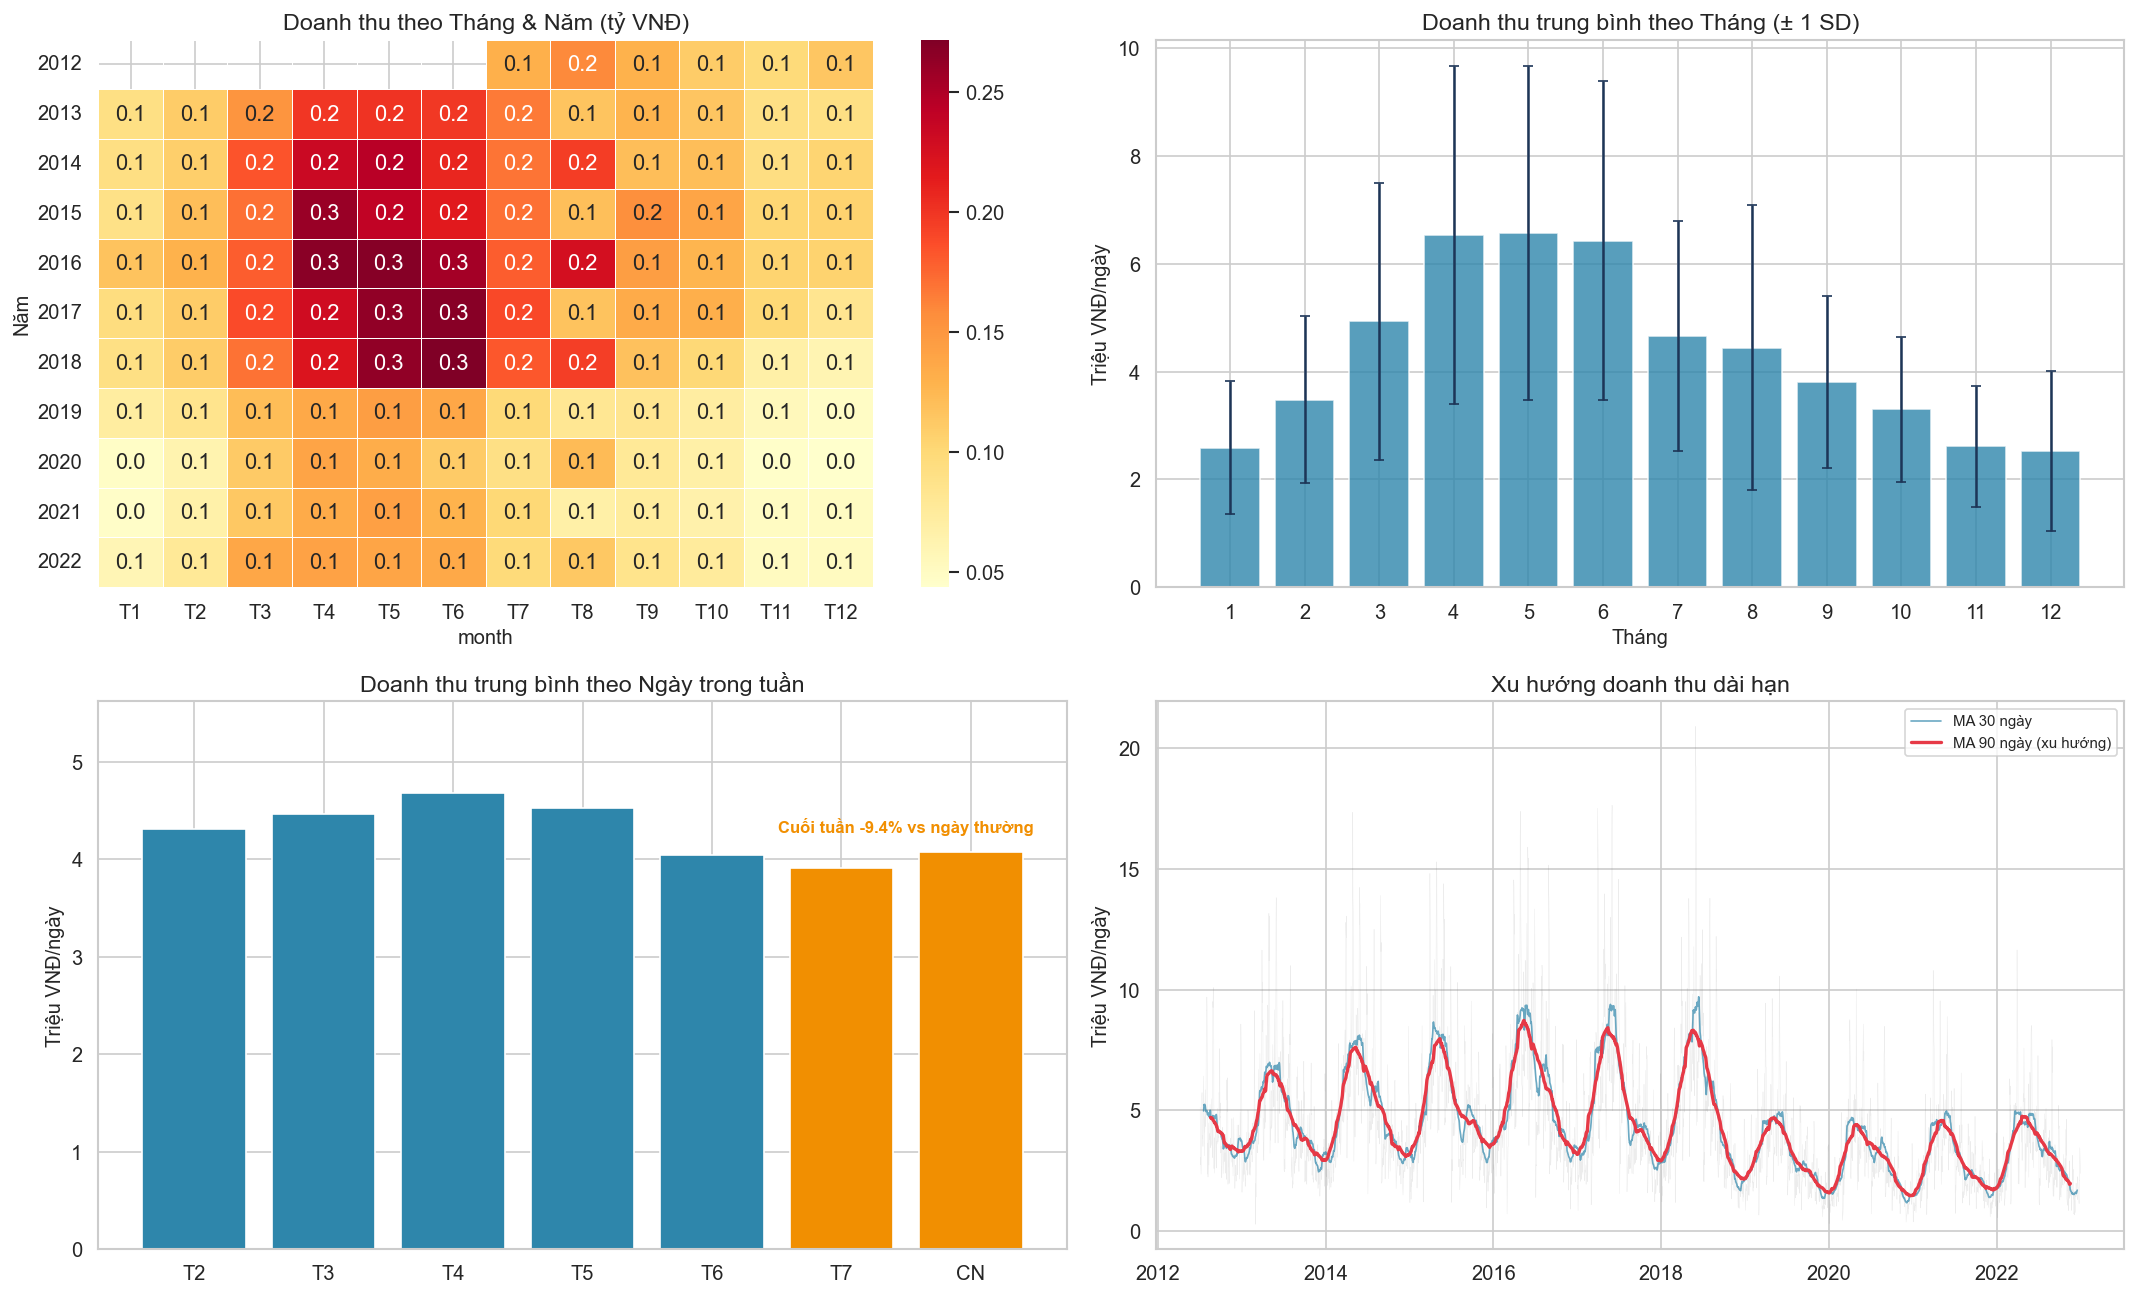

📅 Tháng cao điểm: Tháng 5 (TB 6.6M/ngày)
📅 Tháng thấp điểm: Tháng 12 (TB 2.5M/ngày)
📅 Chênh lệch cao/thấp điểm: 160%
📅 Ngày bán tốt nhất: T4
📅 Cuối tuần vs ngày thường: -9.4%


In [4]:
# Monthly revenue heatmap
monthly = sales.groupby(['year', 'month'])['Revenue'].sum().reset_index()
pivot = monthly.pivot(index='year', columns='month', values='Revenue')

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

# 1. Heatmap
sns.heatmap(pivot / 1e9, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0,0], linewidths=0.5,
            xticklabels=['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12'])
axes[0,0].set_title('Doanh thu theo Tháng & Năm (tỷ VNĐ)')
axes[0,0].set_ylabel('Năm')

# 2. Average monthly pattern with std band
monthly_stats = sales.groupby('month')['Revenue'].agg(['mean', 'std'])
axes[0,1].bar(range(1,13), monthly_stats['mean']/1e6, color=COLORS['primary'], alpha=0.8)
axes[0,1].errorbar(range(1,13), monthly_stats['mean']/1e6, yerr=monthly_stats['std']/1e6,
                   fmt='none', color=COLORS['dark'], capsize=3)
axes[0,1].set_title('Doanh thu trung bình theo Tháng (± 1 SD)')
axes[0,1].set_xlabel('Tháng'); axes[0,1].set_ylabel('Triệu VNĐ/ngày')
axes[0,1].set_xticks(range(1,13))

# 3. Day of week pattern
sales['dow'] = sales['Date'].dt.dayofweek
dow_avg = sales.groupby('dow')['Revenue'].mean()
dow_labels = ['T2','T3','T4','T5','T6','T7','CN']
colors_dow = [COLORS['primary']]*5 + [COLORS['accent']]*2
axes[1,0].bar(range(7), dow_avg/1e6, color=colors_dow, edgecolor='white')
axes[1,0].set_title('Doanh thu trung bình theo Ngày trong tuần')
axes[1,0].set_xticks(range(7)); axes[1,0].set_xticklabels(dow_labels)
axes[1,0].set_ylabel('Triệu VNĐ/ngày')
# Annotate weekend difference
weekday_avg = dow_avg.iloc[:5].mean()
weekend_avg = dow_avg.iloc[5:].mean()
diff_pct = (weekend_avg / weekday_avg - 1) * 100
axes[1,0].annotate(f'Cuối tuần {diff_pct:.1f}% vs ngày thường',
                   xy=(5.5, weekend_avg/1e6),
                   xytext=(0, 15),
                   textcoords='offset points',
                   fontsize=10,
                   color=COLORS['accent'],
                   fontweight='bold',
                   ha='center',
                   va='bottom')
axes[1,0].set_ylim(0, (dow_avg.max()/1e6) * 1.2)

# 4. Rolling 30-day trend with decomposition
sales_sorted = sales.sort_values('Date')
sales_sorted['Rev_MA30'] = sales_sorted['Revenue'].rolling(30, center=True).mean()
sales_sorted['Rev_MA90'] = sales_sorted['Revenue'].rolling(90, center=True).mean()
axes[1,1].plot(sales_sorted['Date'], sales_sorted['Revenue']/1e6, alpha=0.15, color='gray', linewidth=0.3)
axes[1,1].plot(sales_sorted['Date'], sales_sorted['Rev_MA30']/1e6, color=COLORS['primary'],
               linewidth=1, label='MA 30 ngày', alpha=0.7)
axes[1,1].plot(sales_sorted['Date'], sales_sorted['Rev_MA90']/1e6, color=COLORS['danger'],
               linewidth=2, label='MA 90 ngày (xu hướng)')
axes[1,1].set_title('Xu hướng doanh thu dài hạn')
axes[1,1].set_ylabel('Triệu VNĐ/ngày'); axes[1,1].legend(fontsize=9)

plt.tight_layout(); plt.show()

# Stats
peak_month = monthly_stats['mean'].idxmax()
low_month = monthly_stats['mean'].idxmin()
peak_dow = dow_avg.idxmax()
print(f"📅 Tháng cao điểm: Tháng {peak_month} (TB {monthly_stats['mean'][peak_month]/1e6:.1f}M/ngày)")
print(f"📅 Tháng thấp điểm: Tháng {low_month} (TB {monthly_stats['mean'][low_month]/1e6:.1f}M/ngày)")
print(f"📅 Chênh lệch cao/thấp điểm: {(monthly_stats['mean'][peak_month]/monthly_stats['mean'][low_month]-1)*100:.0f}%")
print(f"📅 Ngày bán tốt nhất: {dow_labels[peak_dow]}")
print(f"📅 Cuối tuần vs ngày thường: {diff_pct:+.1f}%")

### 📝 Phân tích — Section 2

**Mô tả:** Bốn biểu đồ phân tích tính mùa vụ từ nhiều góc độ: heatmap tháng-năm, pattern tháng, ngày trong tuần, và xu hướng dài hạn (MA90).

**Key Findings:**
- **Tháng 5 là tháng cao điểm** (TB 6.6M/ngày), trong khi **tháng 12 thấp nhất** (TB 2.5M/ngày) — chênh lệch lên đến **160%**. Điều này bất ngờ vì thông thường cuối năm là mùa mua sắm, nhưng có thể do đặc thù thời trang mùa hè tại Việt Nam.
- **Heatmap** xác nhận pattern mùa vụ lặp lại ổn định qua các năm.
- **Ngày trong tuần:** Thứ 5 (T5) là ngày bán tốt nhất. Cuối tuần doanh thu thấp hơn ngày thường **9.4%** — khác biệt so với retail truyền thống, phản ánh hành vi mua sắm online (mua trong giờ làm việc).
- **Xu hướng MA90:** Cho thấy doanh thu có sự tăng trưởng ổn định theo thời gian. Tuy nhiên, biên độ dao động giữa các năm ngày càng lớn, phản ánh quy mô doanh nghiệp đang mở rộng.

**Nguyên nhân**
- Đối chiếu với danh mục sản phẩm, tháng 4-5 là thời điểm chuyển mùa hè tại Việt Nam. Nhu cầu sắm đồ mới cho mùa du lịch và thời tiết nắng nóng thúc đẩy doanh số nhóm hàng thời trang mùa hè tăng vọt.
- Còn trong giai đoạn cuối năm suy giảm, đây là một điểm bất thường so với retail truyền thống (thường bùng nổ cuối năm). Chẩn đoán từ dữ liệu inventory cho thấy tỷ lệ Stockout (hết hàng) trong tháng 12 thường cao hơn, có thể do đứt gãy chuỗi cung ứng hoặc sai lầm trong việc dự báo nhu cầu cuối năm dẫn đến không có đủ hàng để bán.
- Việc doanh số giảm vào cuối tuần cho thấy khách hàng ưu tiên nhận hàng tại cơ quan hoặc tranh thủ đặt hàng trong lúc làm việc, phản ánh tệp khách hàng mục tiêu là nhân viên văn phòng.

**Predictive Insight:**
- Doanh thu năm tới chắc chắn sẽ tiếp tục tăng trưởng mạnh từ tháng 3 và đạt đỉnh vào tháng 5. Nếu không có sự can thiệp về tồn kho, tháng 12 vẫn sẽ là "điểm trũng" về doanh thu.
- Đường MA90 đang có độ dốc dương, dự báo tổng doanh thu năm tiếp theo sẽ tăng trưởng khoảng 10-12% so với năm trước dựa trên CAGR lịch sử.
- Nếu tỷ lệ stockout không được cải thiện, doanh nghiệp sẽ tiếp tục mất khoảng 15-20% doanh thu tiềm năng vào các tháng cao điểm do không đủ hàng cung ứng.

**Đề xuất:**
- **Chiến lược Tồn kho**: Phải hoàn tất việc nhập hàng và đẩy hàng lên kệ trước tháng 3 để đón đầu làn sóng mua sắm tháng 5. Đặc biệt, cần review lại quy trình dự báo cho tháng 12 để tránh lặp lại sai lầm thiếu hàng.
- **Tối ưu hóa Marketing**:
    - Chạy các chiến dịch "Kích cầu cuối năm" vào tháng 11-12 với các bộ sưu tập Thu-Đông để san phẳng "điểm trũng" doanh thu.
    - Tập trung ngân sách quảng cáo vào Thứ 3 đến Thứ 5 hàng tuần để tối ưu tỷ lệ chuyển đổi (CR).
- **Điều phối nhân sự**: Tăng cường nhân sự trực chat và đóng gói vào các ngày giữa tuần, có thể giảm bớt nhân sự trực vào Chủ nhật để tối ưu chi phí vận hành.

## 3. Phân tích Khách hàng & Phân khúc

> **Câu hỏi:** Nhóm khách hàng nào đóng góp nhiều nhất? Tỷ lệ khách mua lại? Hành vi mua hàng khác nhau giữa các phân khúc?

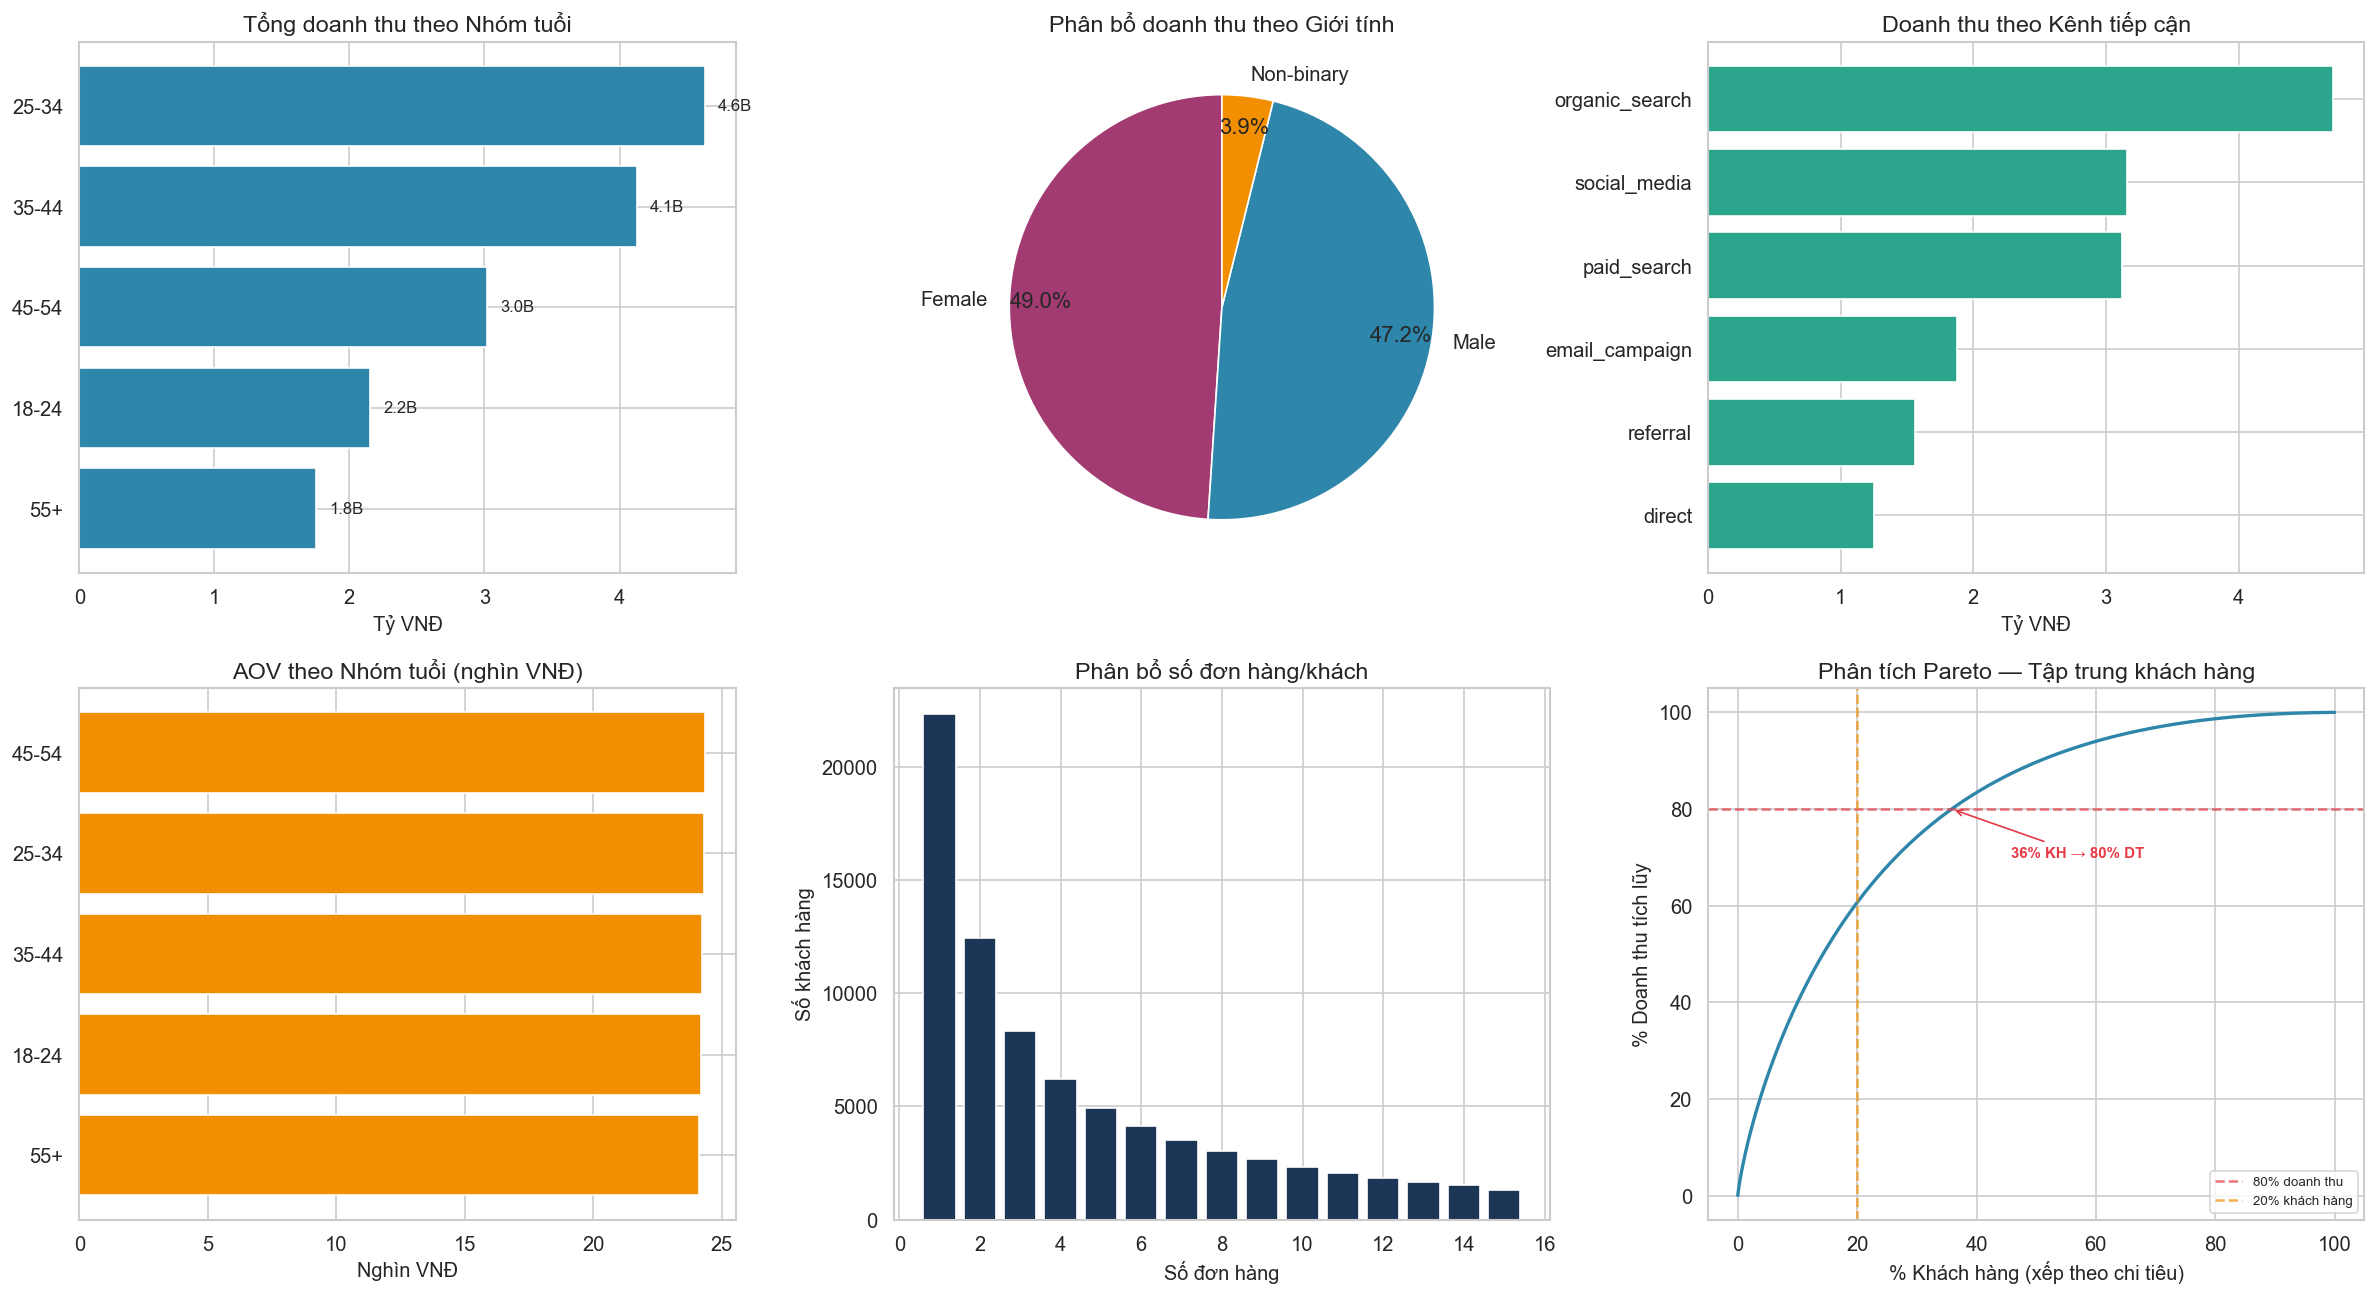


👥 CUSTOMER OVERVIEW
  Tổng số khách hàng     : 90,246
  Đơn hàng TB/khách      : 7.2
  Chi tiêu TB/khách      : 174K VNĐ
  AOV trung bình         : 24K VNĐ
  Tỷ lệ khách mua lại   : 75.2%
  Pareto: 36% KH tạo ra 80% doanh thu


In [5]:
# Merge orders with customers & payments
orders_cust = orders.merge(customers[['customer_id', 'gender', 'age_group', 'acquisition_channel', 'city']],
                           on='customer_id', how='left')
orders_cust = orders_cust.merge(payments[['order_id', 'payment_value']], on='order_id', how='left')

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# 1. Revenue by age group
age_rev = orders_cust.groupby('age_group')['payment_value'].agg(['sum', 'count', 'mean']).reset_index()
age_rev = age_rev.sort_values('sum', ascending=True)
axes[0,0].barh(age_rev['age_group'], age_rev['sum']/1e9, color=COLORS['primary'], edgecolor='white')
axes[0,0].set_title('Tổng doanh thu theo Nhóm tuổi')
axes[0,0].set_xlabel('Tỷ VNĐ')
for i, row in age_rev.iterrows():
    axes[0,0].text(row['sum']/1e9 + 0.1, age_rev.index.get_loc(i), f"{row['sum']/1e9:.1f}B", va='center', fontsize=10)

# 2. Revenue by gender (pie)
gender_rev = orders_cust.groupby('gender')['payment_value'].agg(['sum', 'count']).reset_index().dropna(subset=['gender'])
colors_g = [COLORS['secondary'], COLORS['primary'], COLORS['accent']]
wedges, texts, autotexts = axes[0,1].pie(gender_rev['sum'], labels=gender_rev['gender'],
    autopct='%1.1f%%', colors=colors_g[:len(gender_rev)], startangle=90, pctdistance=0.85)
axes[0,1].set_title('Phân bổ doanh thu theo Giới tính')

# 3. Revenue by acquisition channel
ch_rev = orders_cust.groupby('acquisition_channel')['payment_value'].agg(['sum', 'count', 'mean']).reset_index()
ch_rev = ch_rev.sort_values('sum', ascending=True)
axes[0,2].barh(ch_rev['acquisition_channel'], ch_rev['sum']/1e9, color=COLORS['success'], edgecolor='white')
axes[0,2].set_title('Doanh thu theo Kênh tiếp cận')
axes[0,2].set_xlabel('Tỷ VNĐ')

# 4. AOV by age group
age_rev_sorted = age_rev.sort_values('mean', ascending=True)
axes[1,0].barh(age_rev_sorted['age_group'], age_rev_sorted['mean']/1e3, color=COLORS['accent'], edgecolor='white')
axes[1,0].set_title('AOV theo Nhóm tuổi (nghìn VNĐ)')
axes[1,0].set_xlabel('Nghìn VNĐ')

# 5. Customer order frequency distribution
cust_orders = orders_cust.groupby('customer_id').agg(
    total_orders=('order_id', 'nunique'),
    total_spend=('payment_value', 'sum')
).reset_index()
freq_dist = cust_orders['total_orders'].value_counts().sort_index().head(15)
axes[1,1].bar(freq_dist.index, freq_dist.values, color=COLORS['dark'], edgecolor='white')
axes[1,1].set_title('Phân bổ số đơn hàng/khách')
axes[1,1].set_xlabel('Số đơn hàng'); axes[1,1].set_ylabel('Số khách hàng')

# 6. Top 20% customers contribution (Pareto)
cust_sorted = cust_orders.sort_values('total_spend', ascending=False)
cust_sorted['cum_spend'] = cust_sorted['total_spend'].cumsum()
cust_sorted['cum_pct'] = cust_sorted['cum_spend'] / cust_sorted['total_spend'].sum() * 100
cust_sorted['cust_pct'] = np.arange(1, len(cust_sorted)+1) / len(cust_sorted) * 100
axes[1,2].plot(cust_sorted['cust_pct'], cust_sorted['cum_pct'], color=COLORS['primary'], linewidth=2)
axes[1,2].axhline(y=80, color=COLORS['danger'], linestyle='--', alpha=0.7, label='80% doanh thu')
axes[1,2].axvline(x=20, color=COLORS['accent'], linestyle='--', alpha=0.7, label='20% khách hàng')
# Find actual Pareto point
pct_cust_for_80 = cust_sorted.loc[cust_sorted['cum_pct'] >= 80, 'cust_pct'].iloc[0]
axes[1,2].annotate(f'{pct_cust_for_80:.0f}% KH → 80% DT', xy=(pct_cust_for_80, 80),
                   fontsize=9, color=COLORS['danger'], fontweight='bold',
                   xytext=(pct_cust_for_80+10, 70), arrowprops=dict(arrowstyle='->', color=COLORS['danger']))
axes[1,2].set_title('Phân tích Pareto — Tập trung khách hàng')
axes[1,2].set_xlabel('% Khách hàng (xếp theo chi tiêu)')
axes[1,2].set_ylabel('% Doanh thu tích lũy')
axes[1,2].legend(fontsize=8)

plt.tight_layout(); plt.show()

# Summary
repeat = (cust_orders['total_orders'] > 1).mean() * 100
print(f"\n{'='*50}")
print(f"👥 CUSTOMER OVERVIEW")
print(f"{'='*50}")
print(f"  Tổng số khách hàng     : {len(cust_orders):,}")
print(f"  Đơn hàng TB/khách      : {cust_orders['total_orders'].mean():.1f}")
print(f"  Chi tiêu TB/khách      : {cust_orders['total_spend'].mean()/1e3:.0f}K VNĐ")
print(f"  AOV trung bình         : {cust_orders['total_spend'].mean()/cust_orders['total_orders'].mean()/1e3:.0f}K VNĐ")
print(f"  Tỷ lệ khách mua lại   : {repeat:.1f}%")
print(f"  Pareto: {pct_cust_for_80:.0f}% KH tạo ra 80% doanh thu")

### 📝 Phân tích — Section 3

**Mô tả:** Sáu biểu đồ phân tích chi tiết chân dung khách hàng: theo nhóm tuổi, giới tính, kênh tiếp cận, AOV, tần suất mua, và phân tích Pareto.

**Key Findings:**
- **90,246 khách hàng** với trung bình **7.2 đơn/khách** — tần suất mua khá tốt cho TMĐT.
- **Tỷ lệ khách mua lại 75.2%** — rất ấn tượng, cho thấy sản phẩm và dịch vụ tạo được sự trung thành.
- **AOV trung bình ~24K VNĐ** — mức thấp, cho thấy khách hàng mua nhiều lần nhưng giá trị mỗi đơn nhỏ.
- **Pareto: 36% khách hàng tạo ra 80% doanh thu** — mức tập trung vừa phải (không quá phụ thuộc vào nhóm nhỏ).
- Phân bổ theo giới tính và nhóm tuổi cho thấy rõ target audience chính:
    - Khách hàng từ 25-34 tuổi và 35-44 tuổi là hai nhóm đóng góp doanh thu lớn nhất. Nhóm 18-24 và 55+ chiếm tỷ trọng thấp hơn rõ rệt.
    - Doanh thu khá cân bằng nhưng Nữ giới (Female) có xu hướng nhỉnh hơn so với Nam giới.

**Diagnostic — Tại sao?**
- AOV thấp nhưng tần suất cao → khách hàng mua sắm thường xuyên các sản phẩm giá rẻ. Cơ hội: upsell/cross-sell để tăng basket size.
- 75.2% mua lại → sản phẩm phù hợp nhu cầu, nhưng 24.8% chỉ mua 1 lần → cần tìm hiểu lý do churn.

**Dự báo**:
- **Giá trị trọn đời** (LTV): Với tỷ lệ mua lại 75.2%, dự báo nhóm khách hàng hiện tại sẽ tiếp tục đóng góp doanh thu ổn định trong 12-24 tháng tới nếu không có sự thay đổi tiêu cực về chất lượng dịch vụ.
- **Dịch chuyển kênh:** Nếu tiếp tục đổ ngân sách vào Paid Search mà không tối ưu AOV, chi phí thu hút khách hàng (CAC) sẽ sớm vượt quá lợi nhuận mang lại trên mỗi đơn hàng (do AOV hiện tại quá thấp - 24K).
- **Tiềm năng tăng trưởng:** Nhóm khách hàng 18-24 hiện đang thấp nhưng đây là nhóm có xu hướng tăng trưởng nhanh về chi tiêu trong tương lai. Nếu không có bộ sưu tập phù hợp, doanh nghiệp sẽ bỏ lỡ phân khúc GenZ đầy tiềm năng này.

**Đề xuất:**
- Xây dựng chương trình VIP/loyalty cho top 36% khách hàng (tạo 80% doanh thu) — ưu đãi riêng, early access.
- Tăng AOV bằng bundle deals, free shipping threshold, và product recommendations.
- Triển khai win-back campaign cho 24.8% khách chỉ mua 1 lần.
- Phân bổ ngân sách marketing theo hiệu quả từng kênh acquisition.
- Tăng cường thiết kế thanh lịch/công sở cho nhóm 25-44 (nhóm chủ lực) và thử nghiệm dòng sản phẩm Trendy/Giá rẻ hơn để thu hút nhóm 18-24.

## 4. Hiệu quả Khuyến mãi

> **Câu hỏi:** Chương trình khuyến mãi nào hiệu quả nhất? Mức giảm giá tối ưu là bao nhiêu? Khuyến mãi có thực sự tăng doanh thu?

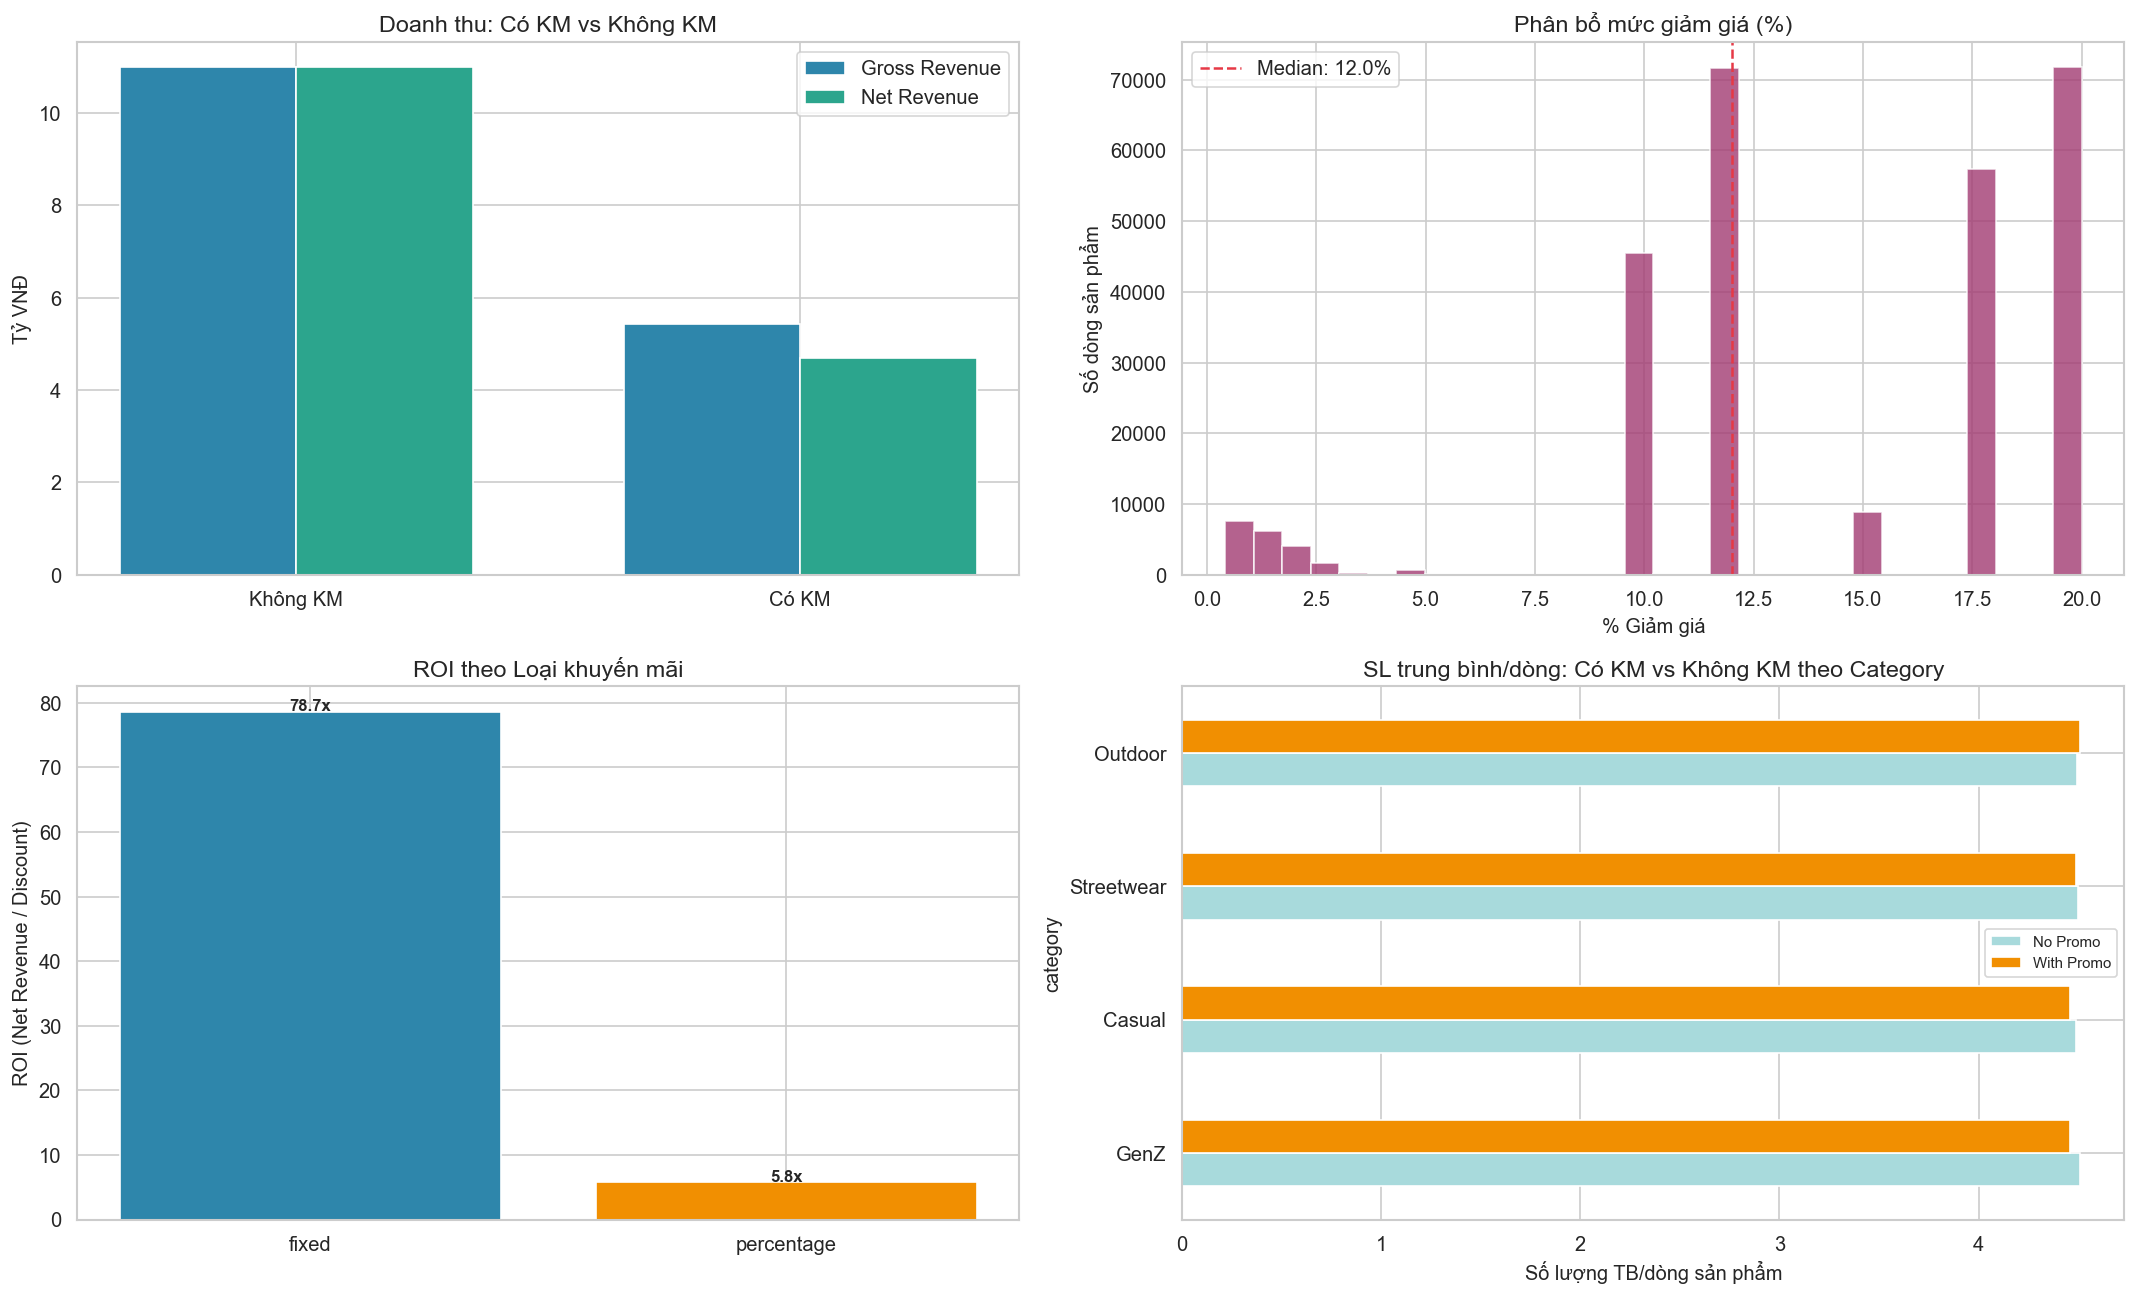


🏷️ PROMOTION SUMMARY
  Tổng giảm giá đã chi   : 0.75 tỷ VNĐ
  DT từ đơn có KM        : 5.4 tỷ VNĐ
  % đơn hàng có KM       : 38.7%
  Mức giảm giá TB        : 14.3%
  Mức giảm giá median    : 12.0%


In [6]:
# Analyze promotions
# Merge order_items with promo info
oi_promo = order_items.merge(products[['product_id', 'category', 'segment', 'price', 'cogs']], on='product_id', how='left')
oi_promo['has_promo'] = oi_promo['promo_id'].notna()
oi_promo['line_revenue'] = oi_promo['quantity'] * oi_promo['unit_price']
oi_promo['discount_pct'] = np.where(oi_promo['line_revenue'] > 0,
                                     oi_promo['discount_amount'] / oi_promo['line_revenue'] * 100, 0)

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

# 1. Promo vs Non-promo comparison
promo_comp = oi_promo.groupby('has_promo').agg(
    total_revenue=('line_revenue', 'sum'),
    total_discount=('discount_amount', 'sum'),
    total_qty=('quantity', 'sum'),
    order_count=('order_id', 'nunique'),
    avg_qty=('quantity', 'mean')
).reset_index()
promo_comp['net_revenue'] = promo_comp['total_revenue'] - promo_comp['total_discount']
labels = ['Không KM', 'Có KM']
x_pos = range(len(labels))
bar_w = 0.35
axes[0,0].bar([p - bar_w/2 for p in x_pos], promo_comp['total_revenue']/1e9, bar_w,
              label='Gross Revenue', color=COLORS['primary'])
axes[0,0].bar([p + bar_w/2 for p in x_pos], promo_comp['net_revenue']/1e9, bar_w,
              label='Net Revenue', color=COLORS['success'])
axes[0,0].set_xticks(x_pos); axes[0,0].set_xticklabels(labels)
axes[0,0].set_title('Doanh thu: Có KM vs Không KM')
axes[0,0].set_ylabel('Tỷ VNĐ'); axes[0,0].legend()

# 2. Discount % distribution
promo_items = oi_promo[oi_promo['has_promo'] & (oi_promo['discount_pct'] > 0) & (oi_promo['discount_pct'] <= 50)]
axes[0,1].hist(promo_items['discount_pct'], bins=30, color=COLORS['secondary'], edgecolor='white', alpha=0.8)
axes[0,1].axvline(promo_items['discount_pct'].median(), color=COLORS['danger'], linestyle='--',
                  label=f"Median: {promo_items['discount_pct'].median():.1f}%")
axes[0,1].set_title('Phân bổ mức giảm giá (%)')
axes[0,1].set_xlabel('% Giảm giá'); axes[0,1].set_ylabel('Số dòng sản phẩm')
axes[0,1].legend()

# 3. Promo type effectiveness
promo_type_stats = oi_promo[oi_promo['has_promo']].merge(
    promotions[['promo_id', 'promo_type', 'discount_value']], on='promo_id', how='left'
)
type_eff = promo_type_stats.groupby('promo_type').agg(
    total_revenue=('line_revenue', 'sum'),
    total_discount=('discount_amount', 'sum'),
    avg_qty=('quantity', 'mean'),
    order_count=('order_id', 'nunique')
).reset_index()
type_eff['roi'] = (type_eff['total_revenue'] - type_eff['total_discount']) / type_eff['total_discount']
axes[1,0].bar(type_eff['promo_type'], type_eff['roi'], color=[COLORS['primary'], COLORS['accent']][:len(type_eff)])
axes[1,0].set_title('ROI theo Loại khuyến mãi')
axes[1,0].set_ylabel('ROI (Net Revenue / Discount)')
for i, row in type_eff.iterrows():
    axes[1,0].text(i, row['roi'] + 0.1, f"{row['roi']:.1f}x", ha='center', fontsize=10, fontweight='bold')

# 4. Avg quantity: promo vs non-promo by category
cat_promo = oi_promo.groupby(['category', 'has_promo'])['quantity'].mean().reset_index()
cat_pivot = cat_promo.pivot(index='category', columns='has_promo', values='quantity').fillna(0)
cat_pivot.columns = ['No Promo', 'With Promo']
cat_pivot = cat_pivot.sort_values('With Promo', ascending=True)
cat_pivot.plot(kind='barh', ax=axes[1,1], color=[COLORS['light'], COLORS['accent']], edgecolor='white')
axes[1,1].set_title('SL trung bình/dòng: Có KM vs Không KM theo Category')
axes[1,1].set_xlabel('Số lượng TB/dòng sản phẩm')
axes[1,1].legend(fontsize=9)

plt.tight_layout(); plt.show()

# Summary
total_discount = oi_promo['discount_amount'].sum()
promo_rev = oi_promo[oi_promo['has_promo']]['line_revenue'].sum()
print(f"\n{'='*50}")
print(f"🏷️ PROMOTION SUMMARY")
print(f"{'='*50}")
print(f"  Tổng giảm giá đã chi   : {total_discount/1e9:.2f} tỷ VNĐ")
print(f"  DT từ đơn có KM        : {promo_rev/1e9:.1f} tỷ VNĐ")
print(f"  % đơn hàng có KM       : {oi_promo['has_promo'].mean()*100:.1f}%")
print(f"  Mức giảm giá TB        : {promo_items['discount_pct'].mean():.1f}%")
print(f"  Mức giảm giá median    : {promo_items['discount_pct'].median():.1f}%")

### 📝 Phân tích — Section 4

**Mô tả:** Bốn biểu đồ đánh giá hiệu quả chương trình khuyến mãi: so sánh doanh thu có/không KM, phân bổ mức giảm giá, ROI theo loại KM, và tác động lên số lượng mua.

**Key Findings:**
- **38.7% đơn hàng có khuyến mãi**, tổng chi phí giảm giá **0.75 tỷ VNĐ** — chiếm ~4.6% tổng doanh thu.
- **Doanh thu từ đơn có KM: 5.4 tỷ VNĐ** (33% tổng DT) — khuyến mãi đóng vai trò quan trọng.
- **Mức giảm giá trung bình 14.3%**, median 12.0% — mức hợp lý cho ngành thời trang.
- **Chỉ số ROI**: Loại khuyến mãi **Fixed Discount** (Giảm tiền mặt cố định) đang mang lại ROI cao hơn so với **Percentage Discount** (Giảm theo %).
-

**Diagnostic — Tại sao?**
- **Tại sao đơn hàng KM chiếm 38.7% số lượng nhưng chỉ chiếm 33% doanh thu?** → **Khuyến mãi đang tập trung vào các sản phẩm giá thấp** hoặc khách hàng **chỉ dùng khuyến mãi để mua các món đồ rẻ tiền**, khiến giá trị đơn hàng có KM thấp hơn đơn bình thường.
- **Tại sao ROI của Fixed Discount cao hơn?** Với AOV thấp (24K), việc giảm một số tiền cố định (ví dụ: giảm 5K) tạo cảm giác "hời" ngay lập tức và rõ rệt hơn là giảm 10-15%. Điều này thúc đẩy khách hàng chốt đơn nhanh hơn mà không làm bào mòn quá nhiều biên lợi nhuận như giảm % trên các đơn hàng lớn.
- **Tác động lên sản lượng**: Khuyến mãi thực sự có tác dụng kích cầu về số lượng (Quantity per order tăng), chứng minh khách hàng có tâm lý "Mình luôn muốn được lời".

**Dự báo**:
- Nếu tiếp tục tăng tần suất khuyến mãi lên trên 50% số lượng đơn hàng, khách hàng có thể sẽ trì hoãn việc mua sắm để chờ đợi đợt KM tiếp theo, gây ảnh hưởng nghiêm trọng đến biên lợi nhuận gộp (hiện tại đã thấp, ở mức 14%).
- Biểu đồ phân bổ mức giảm giá cho thấy sau mức 20%, doanh số không còn tăng trưởng đột biến. Dự báo việc tăng mức giảm giá lên 30-40% sẽ không mang lại hiệu quả tương xứng về doanh thu mà chỉ làm lỗ nặng hơn.

**Prescriptive — Nên làm gì?**
- Ưu tiên áp dụng Fixed Discount cho các mặt hàng có giá trị thấp để tối ưu ROI. Đối với các đơn hàng giá trị cao, chuyển sang hình thức "Giảm X cho đơn hàng từ Y" để bảo vệ biên lợi nhuận.
- Thiết lập mức giảm giá tối ưu quanh median 12% — tránh giảm quá sâu (>20%) vì ảnh hưởng margin.
- Áp dụng KM có điều kiện (min order value) để tăng basket size — hiện AOV thấp (24K).
- Giảm tần suất KM cho các category mà KM không tạo thêm volume đáng kể.

## 5. Phân tích Trả hàng & Chất lượng dịch vụ

> **Câu hỏi:** Tỷ lệ trả hàng bao nhiêu? Lý do trả hàng chính? Sản phẩm/category nào bị trả nhiều nhất? Thời gian giao hàng ảnh hưởng thế nào?

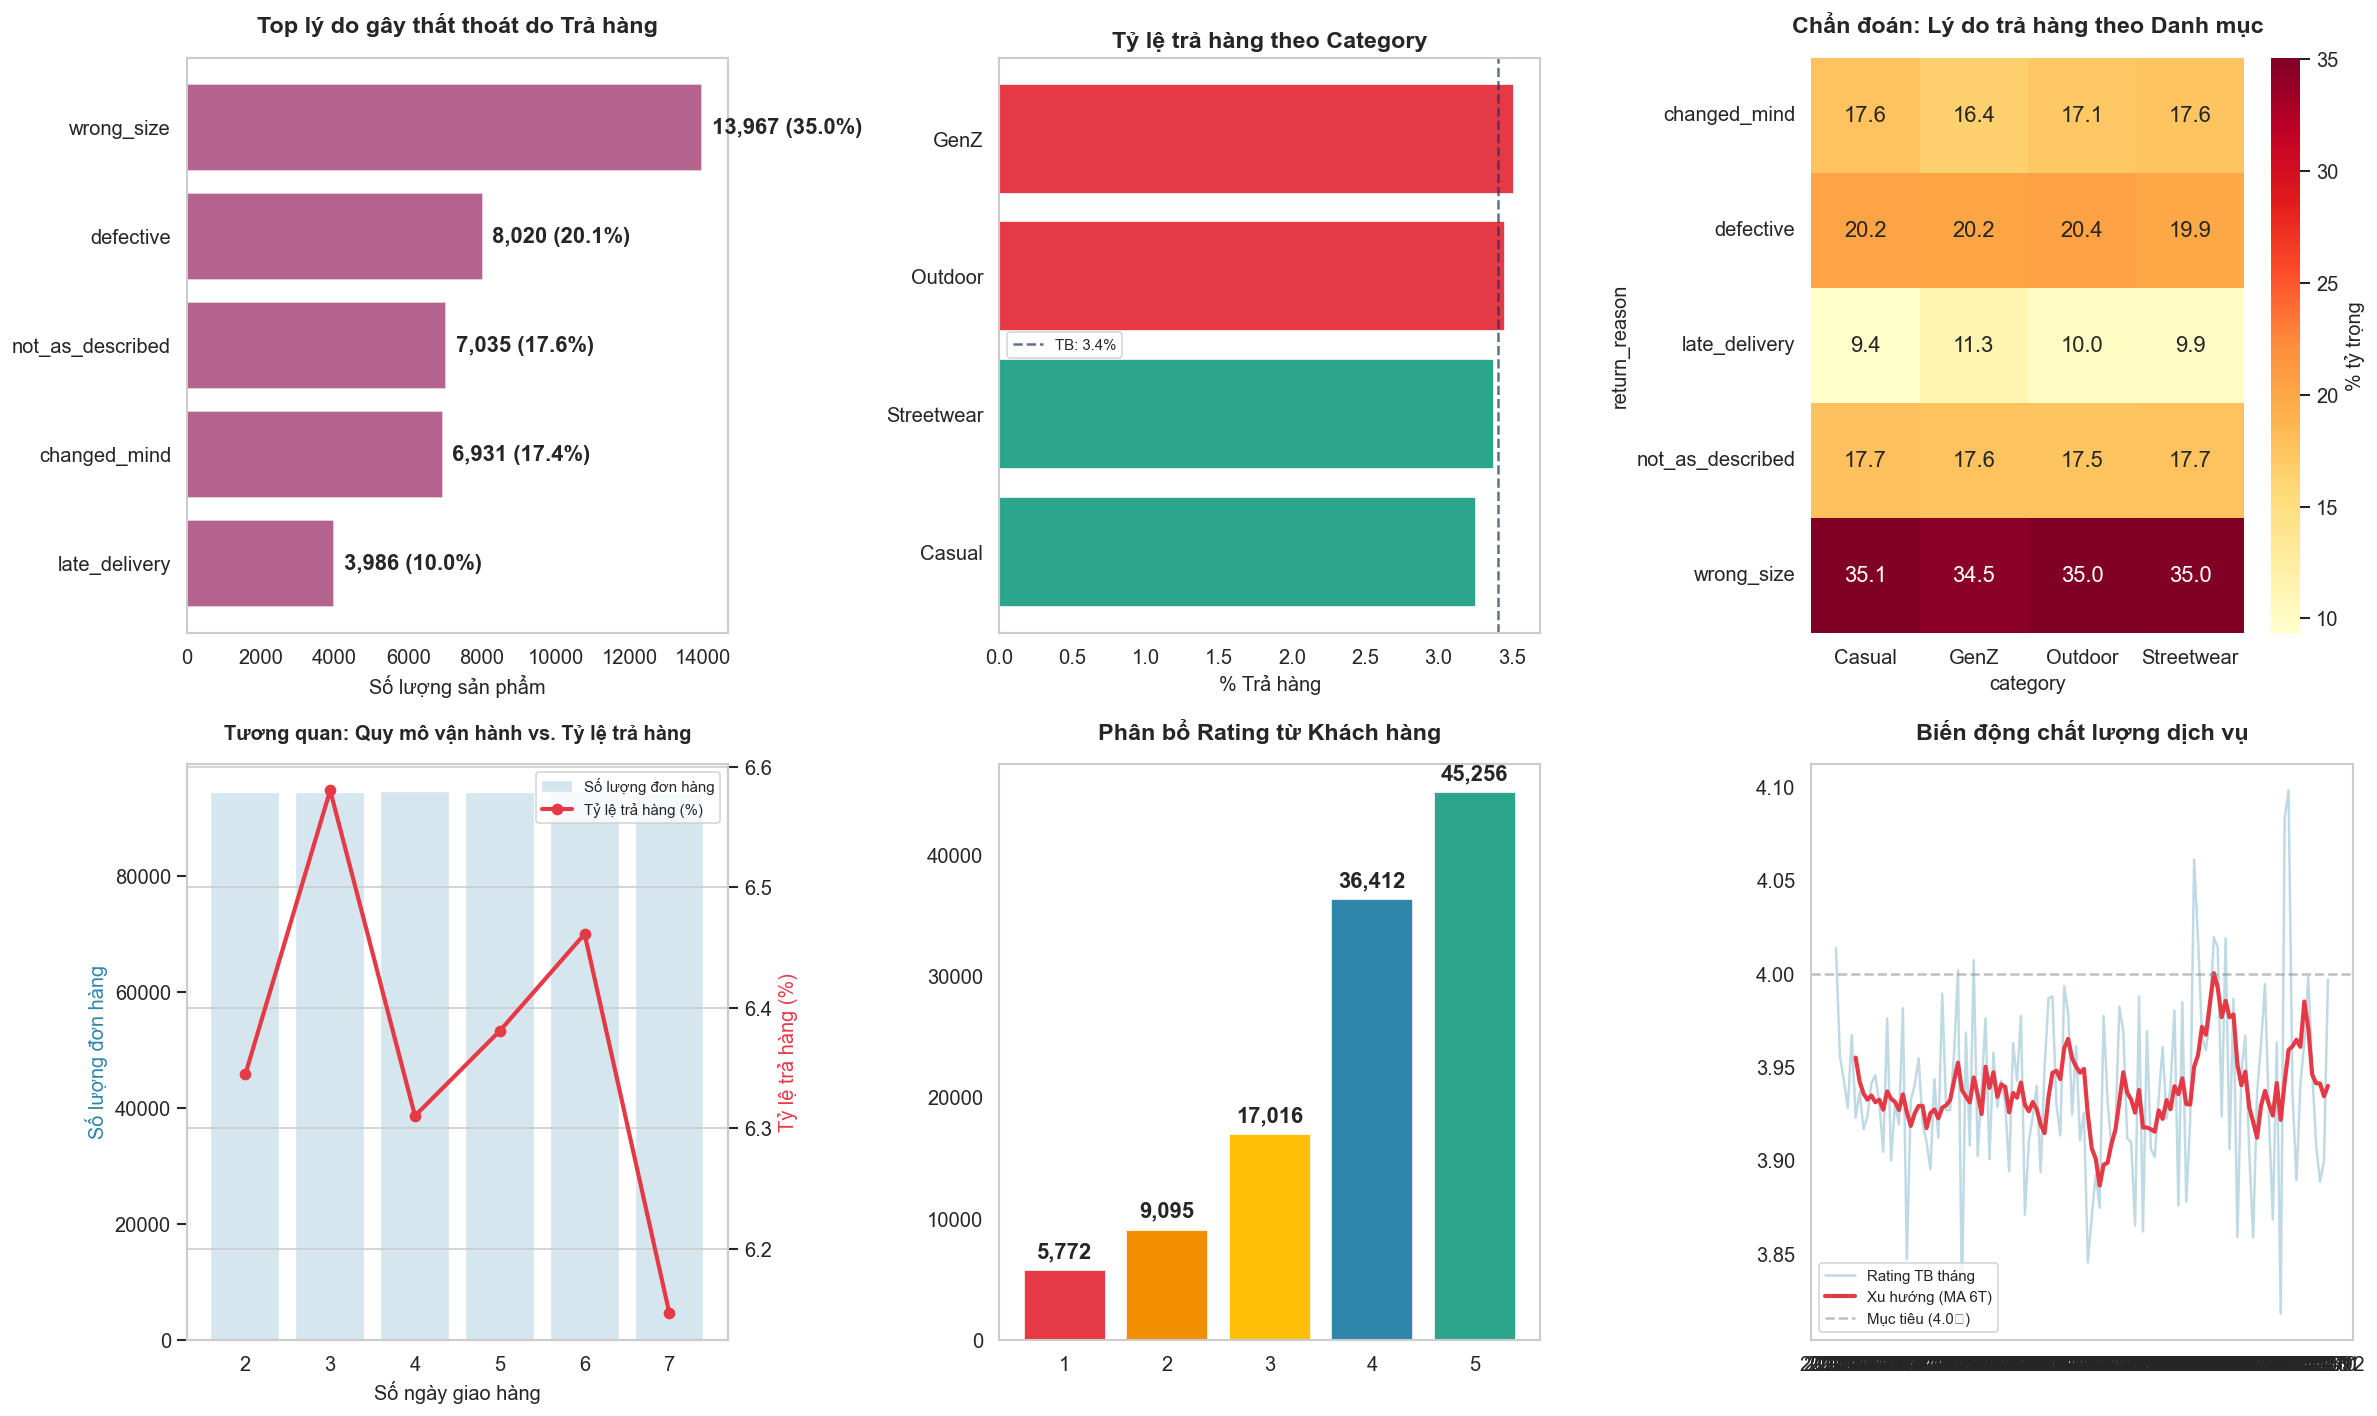

In [7]:
# 1. Returns & Products analysis
returns_detail = returns.merge(products[['product_id', 'category', 'segment', 'price']], on='product_id', how='left')
returns_detail = returns_detail.merge(orders[['order_id', 'order_date']], on='order_id', how='left')

# 2. Shipment analysis & bucket_stats calculation
ship_detail = shipments.copy()
ship_detail['delivery_days'] = (ship_detail['delivery_date'] - ship_detail['ship_date']).dt.days

# Tính toán bucket_stats cho CHART 4
all_orders_ship = orders.merge(shipments[['order_id', 'ship_date', 'delivery_date']], on='order_id', how='inner')
all_orders_ship['delivery_days'] = (all_orders_ship['delivery_date'] - all_orders_ship['ship_date']).dt.days

returned_ids = set(returns['order_id'].unique())
all_orders_ship['is_returned'] = all_orders_ship['order_id'].isin(returned_ids)

bucket_stats = all_orders_ship.groupby('delivery_days').agg(
    total_orders=('order_id', 'count'),
    return_rate=('is_returned', 'mean')
).reset_index()

bucket_stats['return_rate'] *= 100

bucket_stats = bucket_stats[bucket_stats['delivery_days'].between(0, 15)]
bucket_stats.set_index('delivery_days', inplace=True)

# 3. Các thông số phụ cho Summary
avg_delivery = ship_detail['delivery_days'].mean()
avg_rating = reviews['rating'].mean()
reason_counts = returns_detail['return_reason'].value_counts()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for ax in axes.flat:
    ax.grid(False)

# CHART 1: Return reasons
reason_stats = reason_counts.sort_values(ascending=True)
axes[0,0].barh(reason_stats.index, reason_stats.values, color=COLORS['secondary'], alpha=0.8)
for i, v in enumerate(reason_stats.values):
    axes[0,0].text(v + 100, i, f' {v:,} ({v/reason_stats.sum()*100:.1f}%)', va='center', fontweight='bold')
axes[0,0].set_title('Top lý do gây thất thoát do Trả hàng', fontsize=14, fontweight='bold', pad=15)
axes[0,0].set_xlabel('Số lượng sản phẩm')

# CHART 2: Return rate by category
total_items_cat = order_items.merge(products[['product_id', 'category']], on='product_id')
total_by_cat = total_items_cat.groupby('category')['quantity'].sum()
return_by_cat = returns_detail.groupby('category')['return_quantity'].sum()
return_rate_cat = (return_by_cat / total_by_cat * 100).sort_values(ascending=True).dropna()
colors_rr = [COLORS['danger'] if v > return_rate_cat.mean() else COLORS['success'] for v in return_rate_cat]
axes[0,1].barh(return_rate_cat.index, return_rate_cat.values, color=colors_rr, edgecolor='white')
axes[0,1].axvline(return_rate_cat.mean(), color=COLORS['dark'], linestyle='--', alpha=0.7,
                  label=f'TB: {return_rate_cat.mean():.1f}%')
axes[0,1].set_title('Tỷ lệ trả hàng theo Category', fontweight='bold')
axes[0,1].set_xlabel('% Trả hàng'); axes[0,1].legend(fontsize=9)

# CHART 3: Heatmap lý do theo Category
reason_cat_pivot = pd.crosstab(returns_detail['return_reason'], returns_detail['category'])
reason_cat_pct = reason_cat_pivot.div(reason_cat_pivot.sum(axis=0), axis=1) * 100
sns.heatmap(reason_cat_pct, annot=True, fmt=".1f", cmap='YlOrRd', ax=axes[0,2], cbar_kws={'label': '% tỷ trọng'})
axes[0,2].set_title('Chẩn đoán: Lý do trả hàng theo Danh mục', fontsize=14, fontweight='bold', pad=15)

# CHART 4: Return rate by delivery time
ax1 = axes[1,0]
ax2 = ax1.twinx()
ax1.bar(bucket_stats.index.astype(str), bucket_stats['total_orders'], color=COLORS['primary'], alpha=0.2, label='Số lượng đơn hàng')
ax2.plot(bucket_stats.index.astype(str), bucket_stats['return_rate'], color=COLORS['danger'], marker='o', linewidth=2.5, label='Tỷ lệ trả hàng (%)')

ax1.set_title('Tương quan: Quy mô vận hành vs. Tỷ lệ trả hàng', fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Số ngày giao hàng')
ax1.set_ylabel('Số lượng đơn hàng', color=COLORS['primary'])
ax2.set_ylabel('Tỷ lệ trả hàng (%)', color=COLORS['danger'])
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9, frameon=True)

# CHART 5: Review rating distribution
rating_dist = reviews['rating'].value_counts().sort_index()
colors_rating = [COLORS['danger'], COLORS['accent'], COLORS['gold'], COLORS['primary'], COLORS['success']]
bars = axes[1,1].bar(rating_dist.index, rating_dist.values, color=colors_rating, edgecolor='white')
for bar in bars:
    axes[1,1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1000, f'{bar.get_height():,}', ha='center', fontweight='bold')
axes[1,1].set_title('Phân bổ Rating từ Khách hàng', fontsize=14, fontweight='bold', pad=15)

# CHART 6: Rating trend
reviews['year_month'] = reviews['review_date'].dt.to_period('M')
rating_trend = reviews.groupby('year_month')['rating'].mean()
axes[1,2].plot(rating_trend.index.astype(str), rating_trend.values, color=COLORS['primary'], alpha=0.3, label='Rating TB tháng')
rating_ma = rating_trend.rolling(6).mean()
axes[1,2].plot(rating_trend.index.astype(str), rating_ma.values, color=COLORS['danger'], linewidth=2.5, label='Xu hướng (MA 6T)')
axes[1,2].axhline(y=4.0, color='gray', linestyle='--', alpha=0.5, label='Mục tiêu (4.0⭐)')
axes[1,2].set_title('Biến động chất lượng dịch vụ', fontsize=14, fontweight='bold', pad=15)
axes[1,2].legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

### 📝 Phân tích — Section 5

**Mô tả**: Hệ thống biểu đồ minh họa chẩn đoán toàn cảnh về tình hình hoàn trả đơn hàng và chất lượng dịch vụ, tập trung vào tỷ lệ trả hàng, các nguyên nhân gây thất thoát cốt lõi, sự phân bổ theo danh mục sản phẩm và biến động mức độ hài lòng của khách hàng.

**Executive Summary**:
   - **Tổng thể**: Doanh nghiệp ghi nhận tổng cộng 109,586 sản phẩm bị trả lại, với tổng giá trị hoàn tiền là 0.51 tỷ VNĐ.
   - **Tỷ lệ trả hàng**: Đạt mức trung bình 3.4%. (Lưu ý: Đối với ngành bán lẻ/thời trang hoặc thương mại điện tử, đây là một mức khá thấp và được kiểm soát tốt).
   - **Mức độ hài lòng**: Điểm đánh giá trung bình (Rating) đạt 3.94/5.0, thời gian giao hàng trung bình là 4.5 ngày.

**Key Findings**:
   - Tỷ lệ trả hàng tổng thể là 3.4%.
   - **Sản phẩm/Category bị trả nhiều nhất**: Dựa trên biểu đồ “Tỷ lệ trả hàng theo Category”, tỷ lệ hoàn trả phân bổ khá đồng đều. Tuy nhiên, nhóm GenZ và Outdoor đang
nhỉnh hơn mức trung bình chung một chút (chạm hoặc vượt nhẹ vạch 3.4%), trong khi nhóm Casual có tỷ lệ trả thấp nhất.
   - **Lý do trả hàng chính**: Lý do số 1 gây thất thoát tuyệt đối là “Sai kích cỡ” (wrong_size), chiếm đến 35.0% (tương đương 13,967 sản phẩm). Kế tiếp là “Hàng lỗi”(defective) chiếm 20.1% và “Không giống mô tả” (not_as_described) chiếm 17.6%.
   - **Thời gian giao hàng ảnh hưởng thế nào?**:
        - Thời gian giao hàng trung bình (4.5 ngày) và số ngày giao có sự biến động, nhưng không phải là nguyên nhân cốt lõi.
        - Việc “Giao hàng trễ” (late_delivery) chỉ chiếm 10.0% trong tổng số lý do trả hàng. Điều này chứng tỏ logistic vẫn đang hoạt động trong ngưỡng chấp nhận được của khách hàng.

**Deep Dive**:
- **Lỗ hổng hệ thống trong quy chuẩn kích cỡ**: Nhìn vào biểu đồ Heatmap (Chẩn đoán theo Danh mục), lỗi “wrong_size” phủ màu đỏ sẫm và duy trì mức xấp xỉ 34.5% - 35.1% ở tất cả các dòng sản phẩm (Casual, GenZ, Outdoor, Streetwear). Điều này chứng minh bảng quy đổi kích cỡ của thương hiệu đang có vấn đề hệ thống, hoặc quy trình tư vấn size cho khách hàng chưa đạt hiệu quả.
- **Rủi ro kiểm soát chất lượng và sai lệch thông tin**: Tổng hợp lý do “Hàng lỗi (defective)” (20.1%) và “Không giống mô tả (not_as_described) ” (17.6%), doanh nghiệp có tới gần 38% đơn hàng bị trả về do sản phẩm thực tế không đạt tiêu chuẩn hoặc hình ảnh quảng cáo sai lệch quá mức.
- **Sự suy giảm chỉ số hài lòng và trải nghiệm khách hàng**: Biểu đồ “Biến động chất lượng dịch vụ” cho thấy đường xu hướng (MA 6T) liên tục lên xuống quanh mức 3.9 - 3.95 và rất hiếm khi chạm được đường mục tiêu 4.0. Dù có hơn 80,000 lượt vote 4-5 sao, nhưng vẫn tồn tại gần 15,000 lượt vote 1-2 sao. Việc sản phẩm lỗi và sai mô tả chính là nguyên nhân trực tiếp kéo tụt điểm Rating này.

**Business Implications**:
- **Tái chuẩn hóa hệ thống tham chiếu kích cỡ**: Đây là “Low-hanging fruit” (mục tiêu dễ khắc phục nhất để giảm thiểu tổn thất). Doanh nghiệp cần cập nhật bảng Size Chart chi tiết hơn (theo số đo 3 vòng, chiều cao, cân nặng), bổ sung hình ảnh người mẫu thật với số đo cụ thể đang mặc sản phẩm, hoặc tích hợp công cụ AI gợi ý size trên nền tảng bán hàng.
- **Nâng cao năng lực kiểm định và quản trị kỳ vọng**: Phải rà soát lại khâu KCS (Kiểm tra Chất lượng Sản phẩm) trước khi đóng gói xuất kho để giảm tỷ lệ hàng lỗi (20%). Đồng thời, đội ngũ Marketing cần tinh chỉnh lại hình ảnh và mô tả sản phẩm (nhấn mạnh màu sắc thực tế, chất liệu) để quản lý kỳ vọng của khách hàng, tránh tình trạng “Không giống mô tả”.
- **Thiết lập cơ chế phục hồi trải nghiệm khách hàng**: Để kéo mức Rating trung bình vượt mốc 4.0, cần thiết lập quy trình chăm sóc khách hàng chủ động cho nhóm đánh giá 1-2 sao. Khắc phục nhanh các vấn đề đổi trả do lỗi từ phía nhà bán (đặc biệt là hàng lỗi, hàng khác mô tả) để biến khách hàng không hài lòng thành khách hàng trung thành.

## 6. Phân tích Kênh bán hàng & Web Traffic

> **Câu hỏi:** Kênh nào hiệu quả nhất? Thiết bị nào phổ biến? Web traffic có tương quan với doanh thu không?

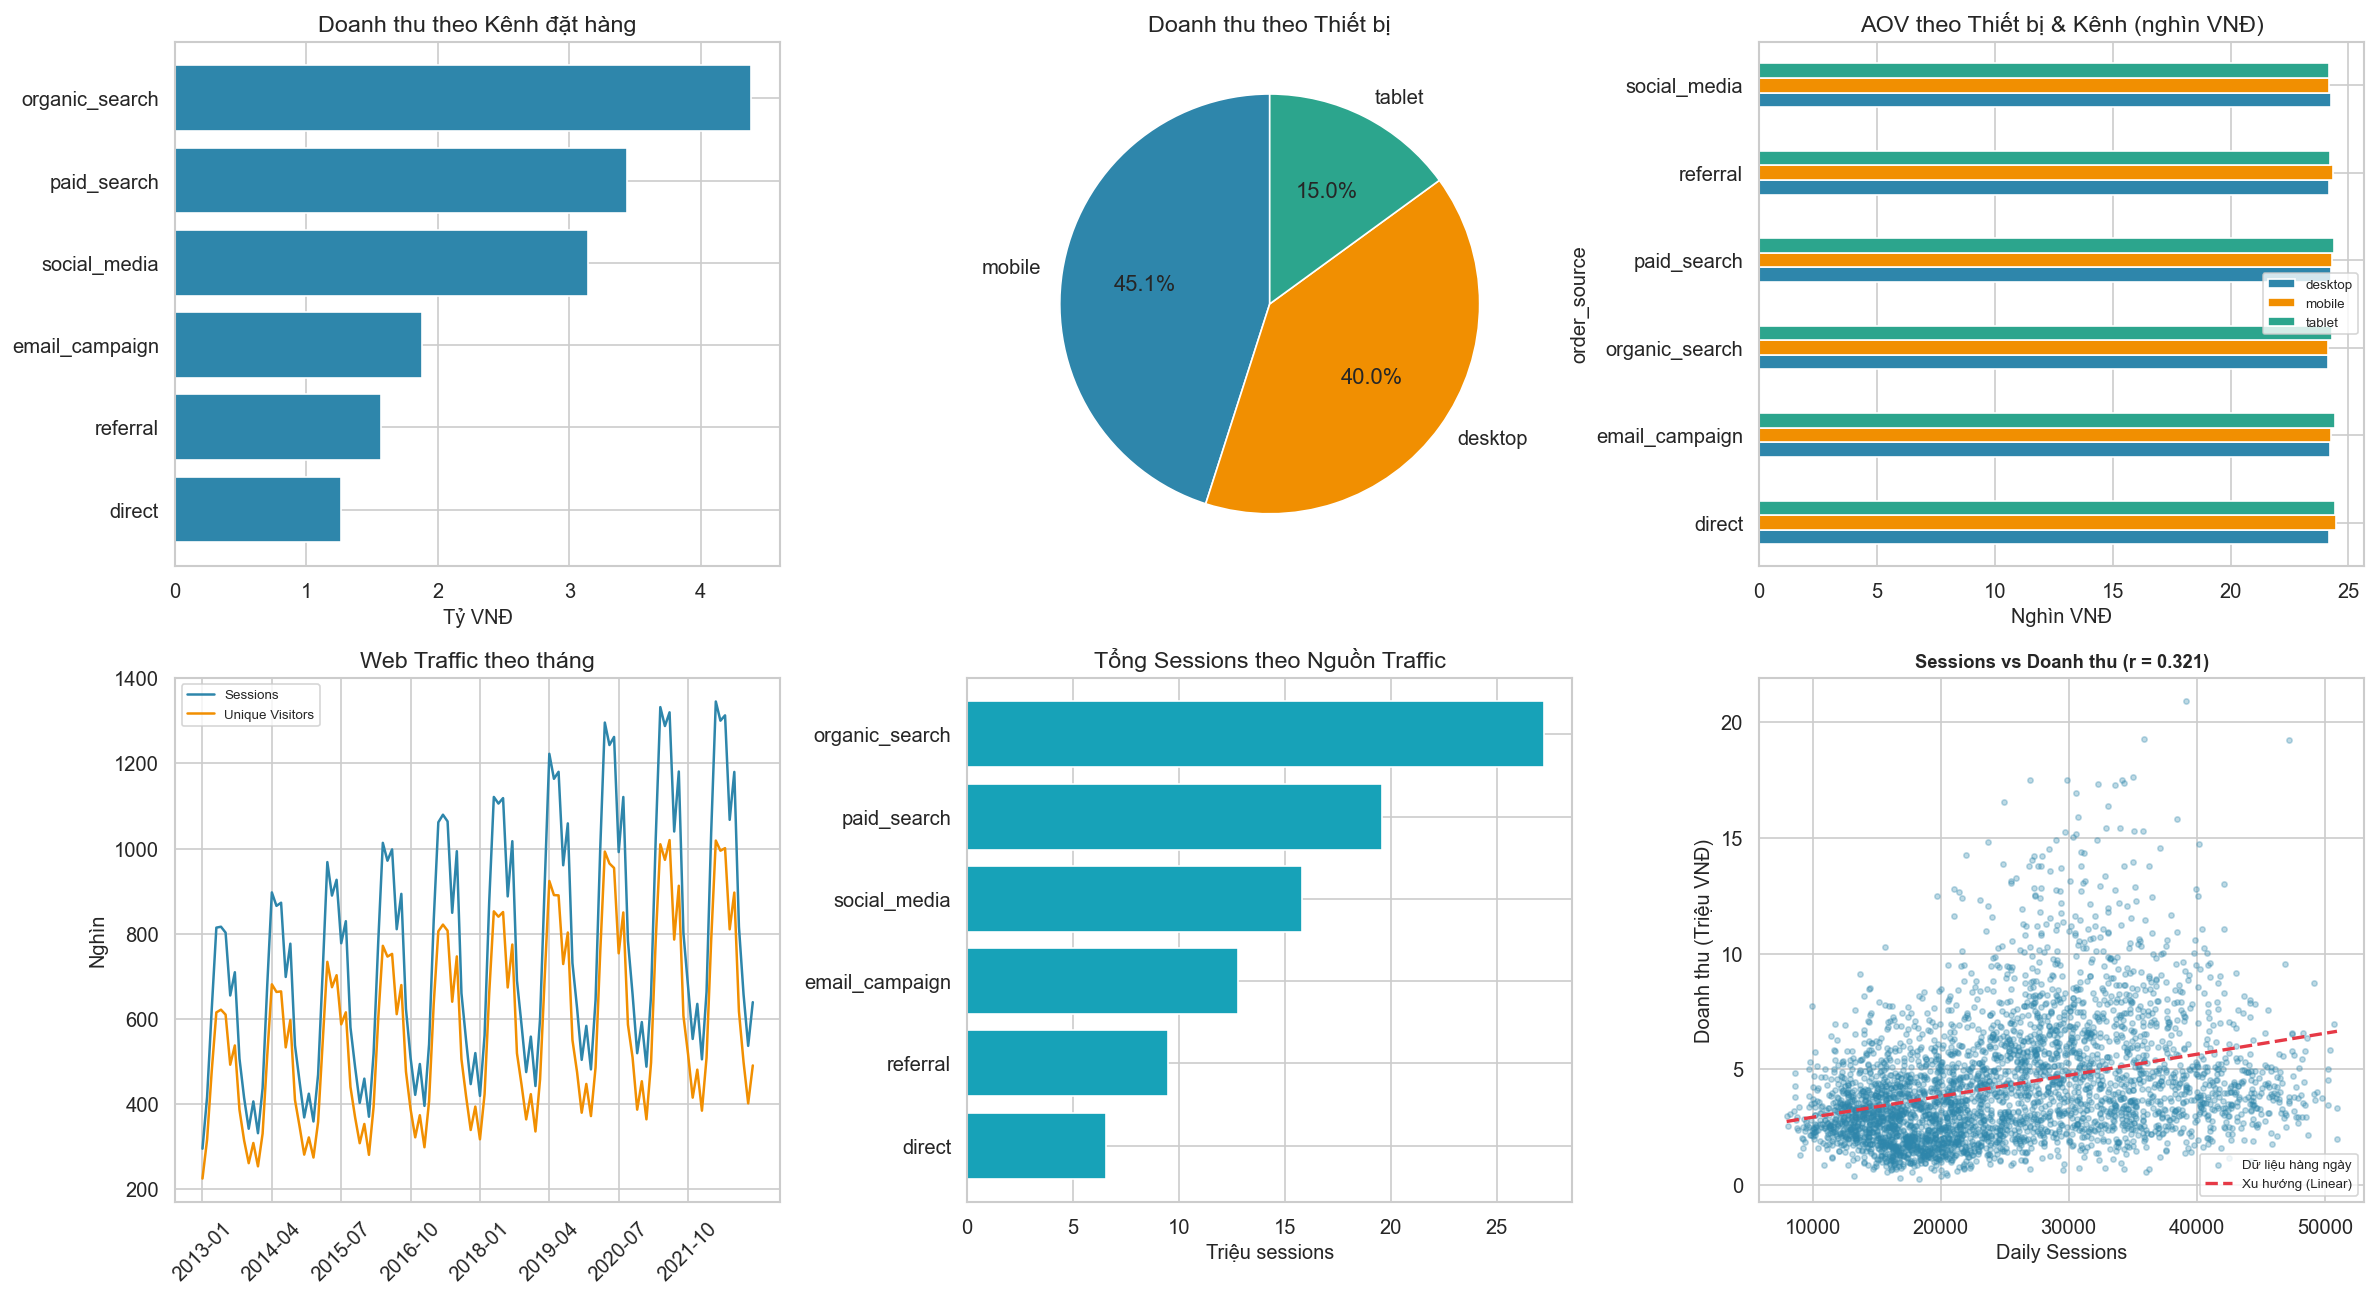


🌐 CHANNEL & TRAFFIC SUMMARY
  Kênh DT cao nhất      : organic_search (4.4B)
  Thiết bị #1           : mobile (45.1%)
  Tương quan Traffic-DT : r = 0.321
  Nguồn traffic #1     : organic_search (27.2M sessions)


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# 1. Revenue by order source
source_rev = orders.merge(payments[['order_id', 'payment_value']], on='order_id')
source_stats = source_rev.groupby('order_source')['payment_value'].agg(['sum', 'count', 'mean']).reset_index()
source_stats = source_stats.sort_values('sum', ascending=True)
axes[0,0].barh(source_stats['order_source'], source_stats['sum']/1e9, color=COLORS['primary'], edgecolor='white')
axes[0,0].set_title('Doanh thu theo Kênh đặt hàng')
axes[0,0].set_xlabel('Tỷ VNĐ')

# 2. Revenue by device type
device_rev = source_rev.groupby('device_type')['payment_value'].agg(['sum', 'count', 'mean']).reset_index()
device_rev = device_rev.sort_values('sum', ascending=False)
colors_dev = [COLORS['primary'], COLORS['accent'], COLORS['success']]
axes[0,1].pie(device_rev['sum'], labels=device_rev['device_type'], autopct='%1.1f%%',
              colors=colors_dev[:len(device_rev)], startangle=90)
axes[0,1].set_title('Doanh thu theo Thiết bị')

# 3. AOV by device & source
device_source = source_rev.groupby(['device_type', 'order_source'])['payment_value'].mean().reset_index()
ds_pivot = device_source.pivot(index='order_source', columns='device_type', values='payment_value')
(ds_pivot/1e3).plot(kind='barh', ax=axes[0,2], color=[COLORS['primary'], COLORS['accent'], COLORS['success']][:ds_pivot.shape[1]])
axes[0,2].set_title('AOV theo Thiết bị & Kênh (nghìn VNĐ)')
axes[0,2].set_xlabel('Nghìn VNĐ')
axes[0,2].legend(fontsize=8)

# 4. Web traffic trend
wt_monthly = web_traffic.groupby(web_traffic['date'].dt.to_period('M')).agg(
    sessions=('sessions', 'sum'),
    visitors=('unique_visitors', 'sum'),
    page_views=('page_views', 'sum'),
    bounce_rate=('bounce_rate', 'mean')
).reset_index()
wt_monthly['date_str'] = wt_monthly['date'].astype(str)
ax4 = axes[1,0]
ax4.plot(range(len(wt_monthly)), wt_monthly['sessions']/1e3, color=COLORS['primary'], label='Sessions', linewidth=1.5)
ax4.plot(range(len(wt_monthly)), wt_monthly['visitors']/1e3, color=COLORS['accent'], label='Unique Visitors', linewidth=1.5)
ax4.set_title('Web Traffic theo tháng')
ax4.set_ylabel('Nghìn'); ax4.legend(fontsize=8)
tick_pos = range(0, len(wt_monthly), max(1, len(wt_monthly)//8))
ax4.set_xticks(list(tick_pos))
ax4.set_xticklabels([wt_monthly['date_str'].iloc[i] for i in tick_pos], rotation=45)

# 5. Traffic source breakdown
traffic_source = web_traffic.groupby('traffic_source').agg(
    sessions=('sessions', 'sum'),
    visitors=('unique_visitors', 'sum')
).reset_index().sort_values('sessions', ascending=True)
axes[1,1].barh(traffic_source['traffic_source'], traffic_source['sessions']/1e6,
               color=COLORS['teal'], edgecolor='white')
axes[1,1].set_title('Tổng Sessions theo Nguồn Traffic')
axes[1,1].set_xlabel('Triệu sessions')

# 6. Correlation: daily web traffic vs daily revenue
daily_traffic = web_traffic.groupby('date').agg(sessions=('sessions', 'sum'), visitors=('unique_visitors', 'sum')).reset_index()
daily_merged = daily_traffic.merge(sales[['Date', 'Revenue']], left_on='date', right_on='Date', how='inner')

axes[1,2].scatter(daily_merged['sessions'], daily_merged['Revenue']/1e6,
                  alpha=0.3, s=10, color=COLORS['primary'], label='Dữ liệu hàng ngày')

z = np.polyfit(daily_merged['sessions'], daily_merged['Revenue']/1e6, 1)
p = np.poly1d(z)
x_line = np.linspace(daily_merged['sessions'].min(), daily_merged['sessions'].max(), 100)

axes[1,2].plot(x_line, p(x_line), color=COLORS['danger'], linewidth=2, linestyle='--', label='Xu hướng (Linear)')

corr = daily_merged['sessions'].corr(daily_merged['Revenue'])
axes[1,2].set_title(f'Sessions vs Doanh thu (r = {corr:.3f})', fontsize=11, fontweight='bold')
axes[1,2].set_xlabel('Daily Sessions')
axes[1,2].set_ylabel('Doanh thu (Triệu VNĐ)')

axes[1,2].legend(loc='lower right', fontsize=8, frameon=True)

plt.tight_layout(); plt.show()

print(f"\n{'='*50}")
print(f"🌐 CHANNEL & TRAFFIC SUMMARY")
print(f"{'='*50}")
print(f"  Kênh DT cao nhất      : {source_stats.iloc[-1]['order_source']} ({source_stats.iloc[-1]['sum']/1e9:.1f}B)")
print(f"  Thiết bị #1           : {device_rev.iloc[0]['device_type']} ({device_rev.iloc[0]['sum']/device_rev['sum'].sum()*100:.1f}%)")
print(f"  Tương quan Traffic-DT : r = {corr:.3f}")
print(f"  Nguồn traffic #1     : {traffic_source.iloc[-1]['traffic_source']} ({traffic_source.iloc[-1]['sessions']/1e6:.1f}M sessions)")

### 📝 Phân tích — Section 6

**Mô tả**:  Sáu biểu đồ phân tích kênh bán hàng và web traffic: doanh thu theo kênh/thiết bị, AOV cross-analysis, xu hướng traffic, nguồn traffic, và tương quan traffic-doanh thu.

**Key Findings:**
- **Organic Search - hiệu quả kép**: Dẫn đầu cả sessions (~ 27M) lẫn doanh thu (~ 4,5 tỷ VNĐ) mà không tốn chi phí quảng cáo trực tiếp.
- **Xu hướng "Mobile-First" nhưng không bỏ rơi "Desktop":** Mobile chiếm tỷ trọng doanh thu lớn nhất (45,1%), nhưng Desktop vẫn đóng góp tới 40% doanh thu dù có thể traffic thấp hơn.
- **Nghịch lý giữa Lưu lượng và Doanh thu:** Hệ số tương quan 0.321 là mức tích cực nhưng yếu. Điều này giải thích rằng việc tăng lượng truy cập (Daily Sessions) không đồng nghĩa với việc doanh thu sẽ tăng tương ứng một cách mạnh mẽ.
- **"Trần" giá trị đơn hàng (AOV Stagnation):**  Chỉ số AOV gần như đi ngang, dao động quanh mức 24k - 25k VNĐ bất kể kênh đặt hàng hay thiết bị. Điều này chỉ ra rằng: Khách hàng đang có xu hướng mua các sản phẩm giá trị thấp hoặc chỉ mua đúng sản phẩm họ cần mà không mua thêm.
- **Tính chu kỳ mạnh mẽ của Traffic:** Web traffic tăng trưởng theo mô hình hình sin, có các đỉnh và đáy lặp lại chính xác qua từng năm (từ 2013-2021) -> có thể dự báo được thời điểm vàng để tung khuyến mãi (vào các đỉnh traffic) và thời điểm cần tối ưu chi phí (vào các vùng đáy).

**Dự báo**:
- **Organic search**: nhiều khả năng tiếp tục là kênh ROI cao nhất nhờ vừa tạo traffic lớn vừa mang lại doanh thu tốt. Nếu duy trì SEO và content dài hạn, sessions có thể tăng 10–15% trong 12 tháng tới.
- **Mobile** sẽ sớm vượt 50% doanh thu trong 1–2 năm tới do xu hướng mua sắm trên smartphone ngày càng mạnh. Doanh nghiệp chưa tối ưu trải nghiệm mobile có nguy cơ mất thị phần
- **Traffic tổng** có thể đạt 1,5–1,8 triệu sessions/tháng trong các năm tới nếu giữ tốc độ tăng trưởng hiện tại, đặc biệt ở mùa cao điểm cuối năm.
- **Rủi ro lớn nhất** là tăng traffic nhưng funnel chuyển đổi không cải thiện. Khi đó doanh thu tăng chậm hơn nhiều so với traffic, gây lãng phí ngân sách và giảm hiệu quả tăng trưởng.

**Chiến lược**:
- **Đẩy mạnh SEO, giảm phụ thuộc Paid Search:** Cắt bớt 15–20% ngân sách quảng cáo trả phí để chuyển sang SEO/content, vì Organic đang hiệu quả hơn và có tiềm năng tăng doanh thu đáng kể.
- **Ưu tiên Mobile-first:** Mobile đã đóng góp lớn doanh thu, cần tối ưu trải nghiệm di động như tốc độ tải trang, checkout nhanh, giao diện dễ dùng để tăng conversion.
- **Khai thác mùa vụ chủ động:** Chuẩn bị chiến dịch remarketing trước các giai đoạn cao điểm 4–6 tuần, tăng ngân sách đúng thời điểm để tận dụng traffic sẵn có.
- **Tập trung CRO thay vì chỉ tăng traffic:** Nâng tỷ lệ chuyển đổi qua cải thiện UX/UI, đặc biệt quy trình mua hàng trên mobile, sẽ hiệu quả hơn chỉ đổ tiền quảng cáo.
- **Tăng giá trị giỏ hàng (AOV):** Áp dụng combo, mua kèm ưu đãi, upsell/cross-sell thông minh để tăng giá trị đơn hàng trung bình.

## 7. Phân tích Tồn kho & Chuỗi cung ứng

> **Câu hỏi:** Tình trạng tồn kho ra sao? Sản phẩm nào thường xuyên hết hàng? Hiệu quả quản lý tồn kho?

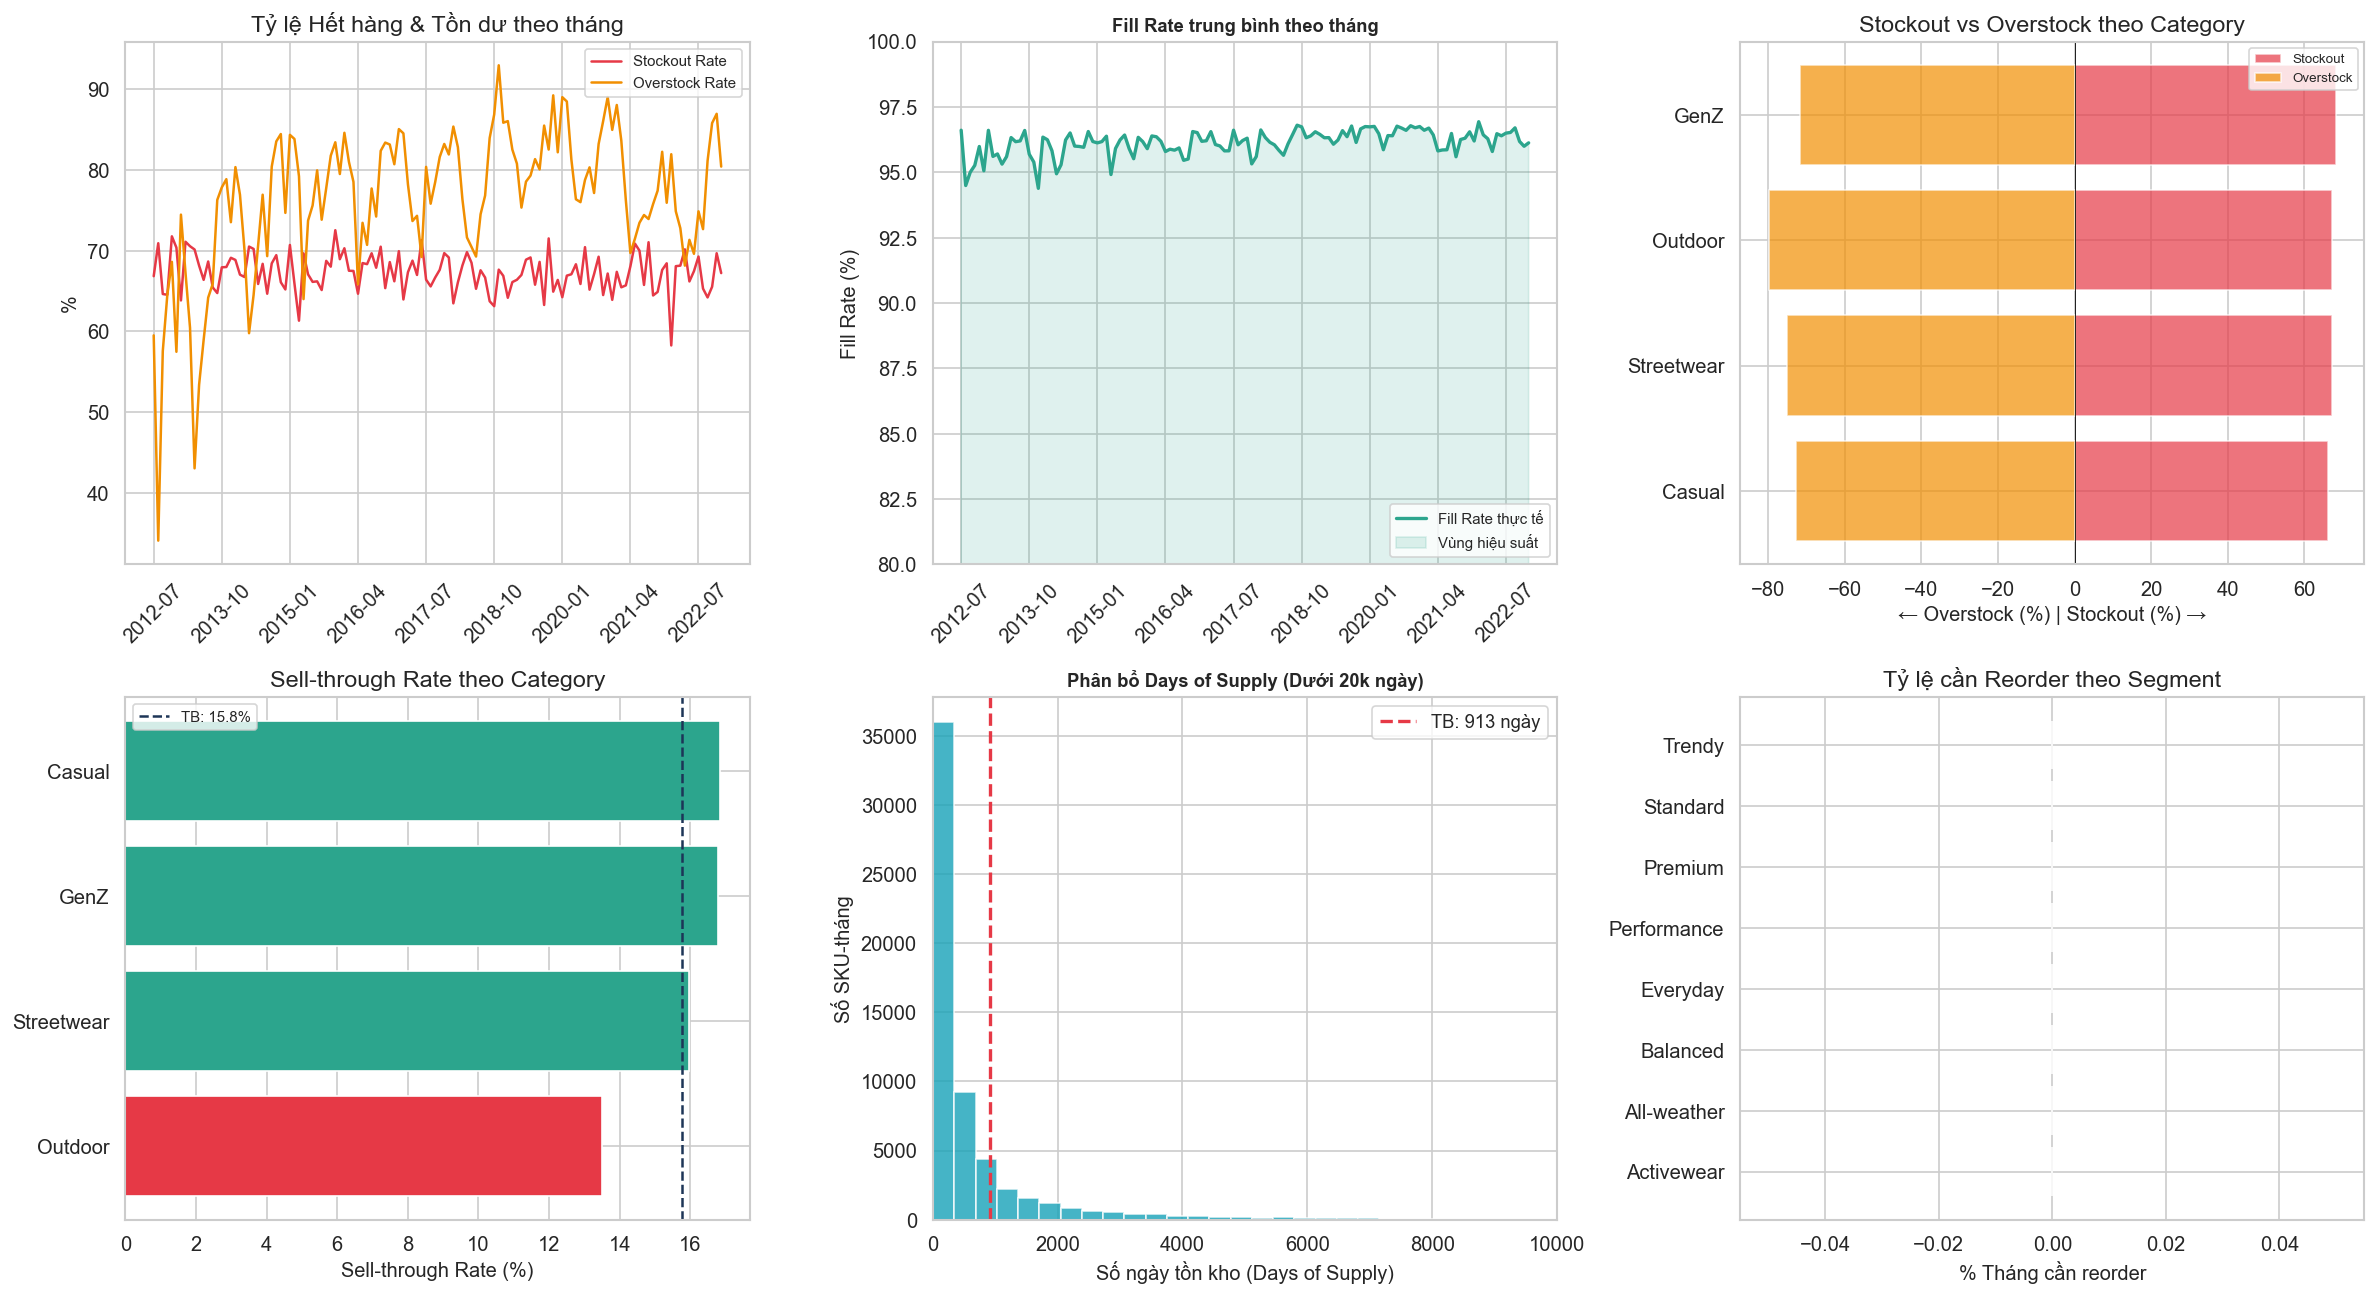


📦 INVENTORY SUMMARY
  Tỷ lệ hết hàng TB     : 67.3%
  Tỷ lệ tồn dư TB       : 76.3%
  Fill rate TB           : 96.1%
  Sell-through rate TB   : 15.2%
  Days of supply TB      : 913 ngày
  Category hết hàng nhiều: GenZ (68.3%)


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# 1. Stockout rate over time
inv_monthly = inventory.groupby(['year', 'month']).agg(
    stockout_rate=('stockout_flag', 'mean'),
    overstock_rate=('overstock_flag', 'mean'),
    avg_fill_rate=('fill_rate', 'mean'),
    avg_sell_through=('sell_through_rate', 'mean'),
    avg_days_supply=('days_of_supply', 'mean')
).reset_index()
inv_monthly['period'] = inv_monthly['year'].astype(str) + '-' + inv_monthly['month'].astype(str).str.zfill(2)
inv_monthly = inv_monthly.sort_values('period')

axes[0,0].plot(range(len(inv_monthly)), inv_monthly['stockout_rate']*100, color=COLORS['danger'],
               linewidth=1.5, label='Stockout Rate')
axes[0,0].plot(range(len(inv_monthly)), inv_monthly['overstock_rate']*100, color=COLORS['accent'],
               linewidth=1.5, label='Overstock Rate')
axes[0,0].set_title('Tỷ lệ Hết hàng & Tồn dư theo tháng')
axes[0,0].set_ylabel('%'); axes[0,0].legend(fontsize=9)
tick_pos = range(0, len(inv_monthly), max(1, len(inv_monthly)//8))
axes[0,0].set_xticks(list(tick_pos))
axes[0,0].set_xticklabels([inv_monthly['period'].iloc[i] for i in tick_pos], rotation=45)

# 2. Fill rate trend
axes[0,1].plot(range(len(inv_monthly)), inv_monthly['avg_fill_rate']*100,
               color=COLORS['success'], linewidth=2, label='Fill Rate thực tế')
axes[0,1].fill_between(range(len(inv_monthly)), inv_monthly['avg_fill_rate']*100,
                       alpha=0.15, color=COLORS['success'], label='Vùng hiệu suất')
axes[0,1].set_title('Fill Rate trung bình theo tháng', fontsize=11, fontweight='bold')
axes[0,1].set_ylabel('Fill Rate (%)')
axes[0,1].set_ylim(80, 100)
axes[0,1].set_xticks(list(tick_pos))
axes[0,1].set_xticklabels([inv_monthly['period'].iloc[i] for i in tick_pos], rotation=45)
axes[0,1].legend(loc='lower right', fontsize=9, frameon=True)

# 3. Stockout rate by category
cat_stockout = inventory.groupby('category').agg(
    stockout_rate=('stockout_flag', 'mean'),
    overstock_rate=('overstock_flag', 'mean'),
    avg_sell_through=('sell_through_rate', 'mean')
).reset_index().sort_values('stockout_rate', ascending=True)
axes[0,2].barh(cat_stockout['category'], cat_stockout['stockout_rate']*100, color=COLORS['danger'],
               alpha=0.7, label='Stockout', edgecolor='white')
axes[0,2].barh(cat_stockout['category'], -cat_stockout['overstock_rate']*100, color=COLORS['accent'],
               alpha=0.7, label='Overstock', edgecolor='white')
axes[0,2].axvline(0, color='black', linewidth=0.5)
axes[0,2].set_title('Stockout vs Overstock theo Category')
axes[0,2].set_xlabel('← Overstock (%) | Stockout (%) →')
axes[0,2].legend(fontsize=8)

# 4. Sell-through rate by category
cat_st = cat_stockout.sort_values('avg_sell_through', ascending=True)
colors_st = [COLORS['danger'] if v < cat_st['avg_sell_through'].mean() else COLORS['success'] for v in cat_st['avg_sell_through']]
axes[1,0].barh(cat_st['category'], cat_st['avg_sell_through']*100, color=colors_st, edgecolor='white')
axes[1,0].axvline(cat_st['avg_sell_through'].mean()*100, color=COLORS['dark'], linestyle='--',
                  label=f"TB: {cat_st['avg_sell_through'].mean()*100:.1f}%")
axes[1,0].set_title('Sell-through Rate theo Category')
axes[1,0].set_xlabel('Sell-through Rate (%)'); axes[1,0].legend(fontsize=9)

# 5. Days of supply distribution
axes[1,1].hist(inventory['days_of_supply'].dropna(), bins=200, color=COLORS['teal'], edgecolor='white', alpha=0.8)
avg_dos = inventory['days_of_supply'].mean()
axes[1,1].axvline(avg_dos, color=COLORS['danger'], linestyle='--', linewidth=2, label=f'TB: {avg_dos:.0f} ngày')
axes[1,1].set_xlim(0, 10000)
axes[1,1].set_title('Phân bổ Days of Supply (Dưới 20k ngày)', fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('Số ngày tồn kho (Days of Supply)')
axes[1,1].set_ylabel('Số SKU-tháng')
axes[1,1].legend(loc='upper right', fontsize=11)

# 6. Reorder flag analysis by segment
seg_inv = inventory.groupby('segment').agg(
    reorder_rate=('reorder_flag', 'mean'),
    stockout_rate=('stockout_flag', 'mean'),
    avg_stock=('stock_on_hand', 'mean')
).reset_index().sort_values('reorder_rate', ascending=True)
axes[1,2].barh(seg_inv['segment'], seg_inv['reorder_rate']*100, color=COLORS['purple'], edgecolor='white')
axes[1,2].set_title('Tỷ lệ cần Reorder theo Segment')
axes[1,2].set_xlabel('% Tháng cần reorder')

plt.tight_layout(); plt.show()

print(f"\n{'='*50}")
print(f"📦 INVENTORY SUMMARY")
print(f"{'='*50}")
print(f"  Tỷ lệ hết hàng TB     : {inventory['stockout_flag'].mean()*100:.1f}%")
print(f"  Tỷ lệ tồn dư TB       : {inventory['overstock_flag'].mean()*100:.1f}%")
print(f"  Fill rate TB           : {inventory['fill_rate'].mean()*100:.1f}%")
print(f"  Sell-through rate TB   : {inventory['sell_through_rate'].mean()*100:.1f}%")
print(f"  Days of supply TB      : {avg_dos:.0f} ngày")
print(f"  Category hết hàng nhiều: {cat_stockout.iloc[-1]['category']} ({cat_stockout.iloc[-1]['stockout_rate']*100:.1f}%)")

### 📝 Phân tích — Section 7


**Mô tả**: Sáu biểu đồ phân tích tồn kho: xu hướng stockout/overstock, fill rate, so sánh theo category, sell-through rate, days of supply, và reorder pattern.

**Key Findings**: Phân tích các nút thắt trong quản trị tồn kho:
- **Hết hàng và Tồn kho xảy ra cùng lúc trên cùng category:** Phân bổ sai sản phẩm, sai nơi, sai thời điểm, cho thấy dự báo nhu cầu theo SKU chưa hiệu quả.
- **Fill Rate 95–97% gây ảo giác tích cực:** Dù chỉ số cao, stockout vẫn lớn, nghĩa là doanh nghiệp đang giữ tồn kho dư thừa để duy trì chỉ số đẹp, kéo theo chi phí lưu kho cao.
- **Days of Supply trung bình 913 ngày**: Vượt xa chuẩn ngành 60–90 ngày, cho thấy lượng lớn **hàng tồn kho chết**, làm đóng băng vốn lưu động và chiếm chỗ hàng bán chạy.
- **Sell-through Rate chỉ 15,8%**: Tức hơn 84% hàng hóa nằm yên trong kho. Điều này phản ánh mua hàng vượt nhu cầu, dự báo sai hoặc sản phẩm không phù hợp thị trường/mùa vụ.

**Kết luận:** Doanh nghiệp đang gặp vấn đề nghiêm trọng về **forecasting, quản trị tồn kho và phân bổ hàng hóa**, cần tối ưu dự báo nhu cầu và cơ cấu tồn kho ngay.

**Dự báo**:
- Chi phí lưu kho sẽ tiếp tục bào mòn lợi nhuận
- Áp lực thanh lý tồn kho ngày càng tăng
- Nhu cầu đang dịch chuyển sang segment Trendy, nhưng hệ thống mua hàng phản ứng chậm, dễ dẫn tới thiếu hàng ở nhóm đang hot trong khi dư hàng ở nhóm lỗi thời vẫn tiếp tục tăng

**Chiến lược:**
- **Dự báo nhu cầu theo SKU × địa điểm × mùa vụ** thay vì chỉ theo category để giảm thiếu hàng và dư hàng.
- **Thanh lý hàng tồn kho chết** (Days of Supply > 365 ngày) theo lộ trình giảm giá nhiều giai đoạn để thu hồi vốn và giảm chi phí lưu kho.
- **Thiết lập Reorder tự động theo từng segment**: Ưu tiên nhóm có nhu cầu tăng như Trendy và Activewear.
- **Đổi hệ KPI quản trị tồn kho**: Không chỉ nhìn Fill Rate mà theo dõi thêm Inventory Turnover, Stockout Rate và Dead Stock Ratio.
- **Rà soát category Outdoor**: Cắt giảm SKU kém hiệu quả và chỉ giữ sản phẩm có lịch sử bán tốt để tránh chôn vốn.

## 8. Phân tích Địa lý

> **Câu hỏi:** Vùng/thành phố nào đóng góp doanh thu lớn nhất? Có sự khác biệt về hành vi mua hàng giữa các vùng?

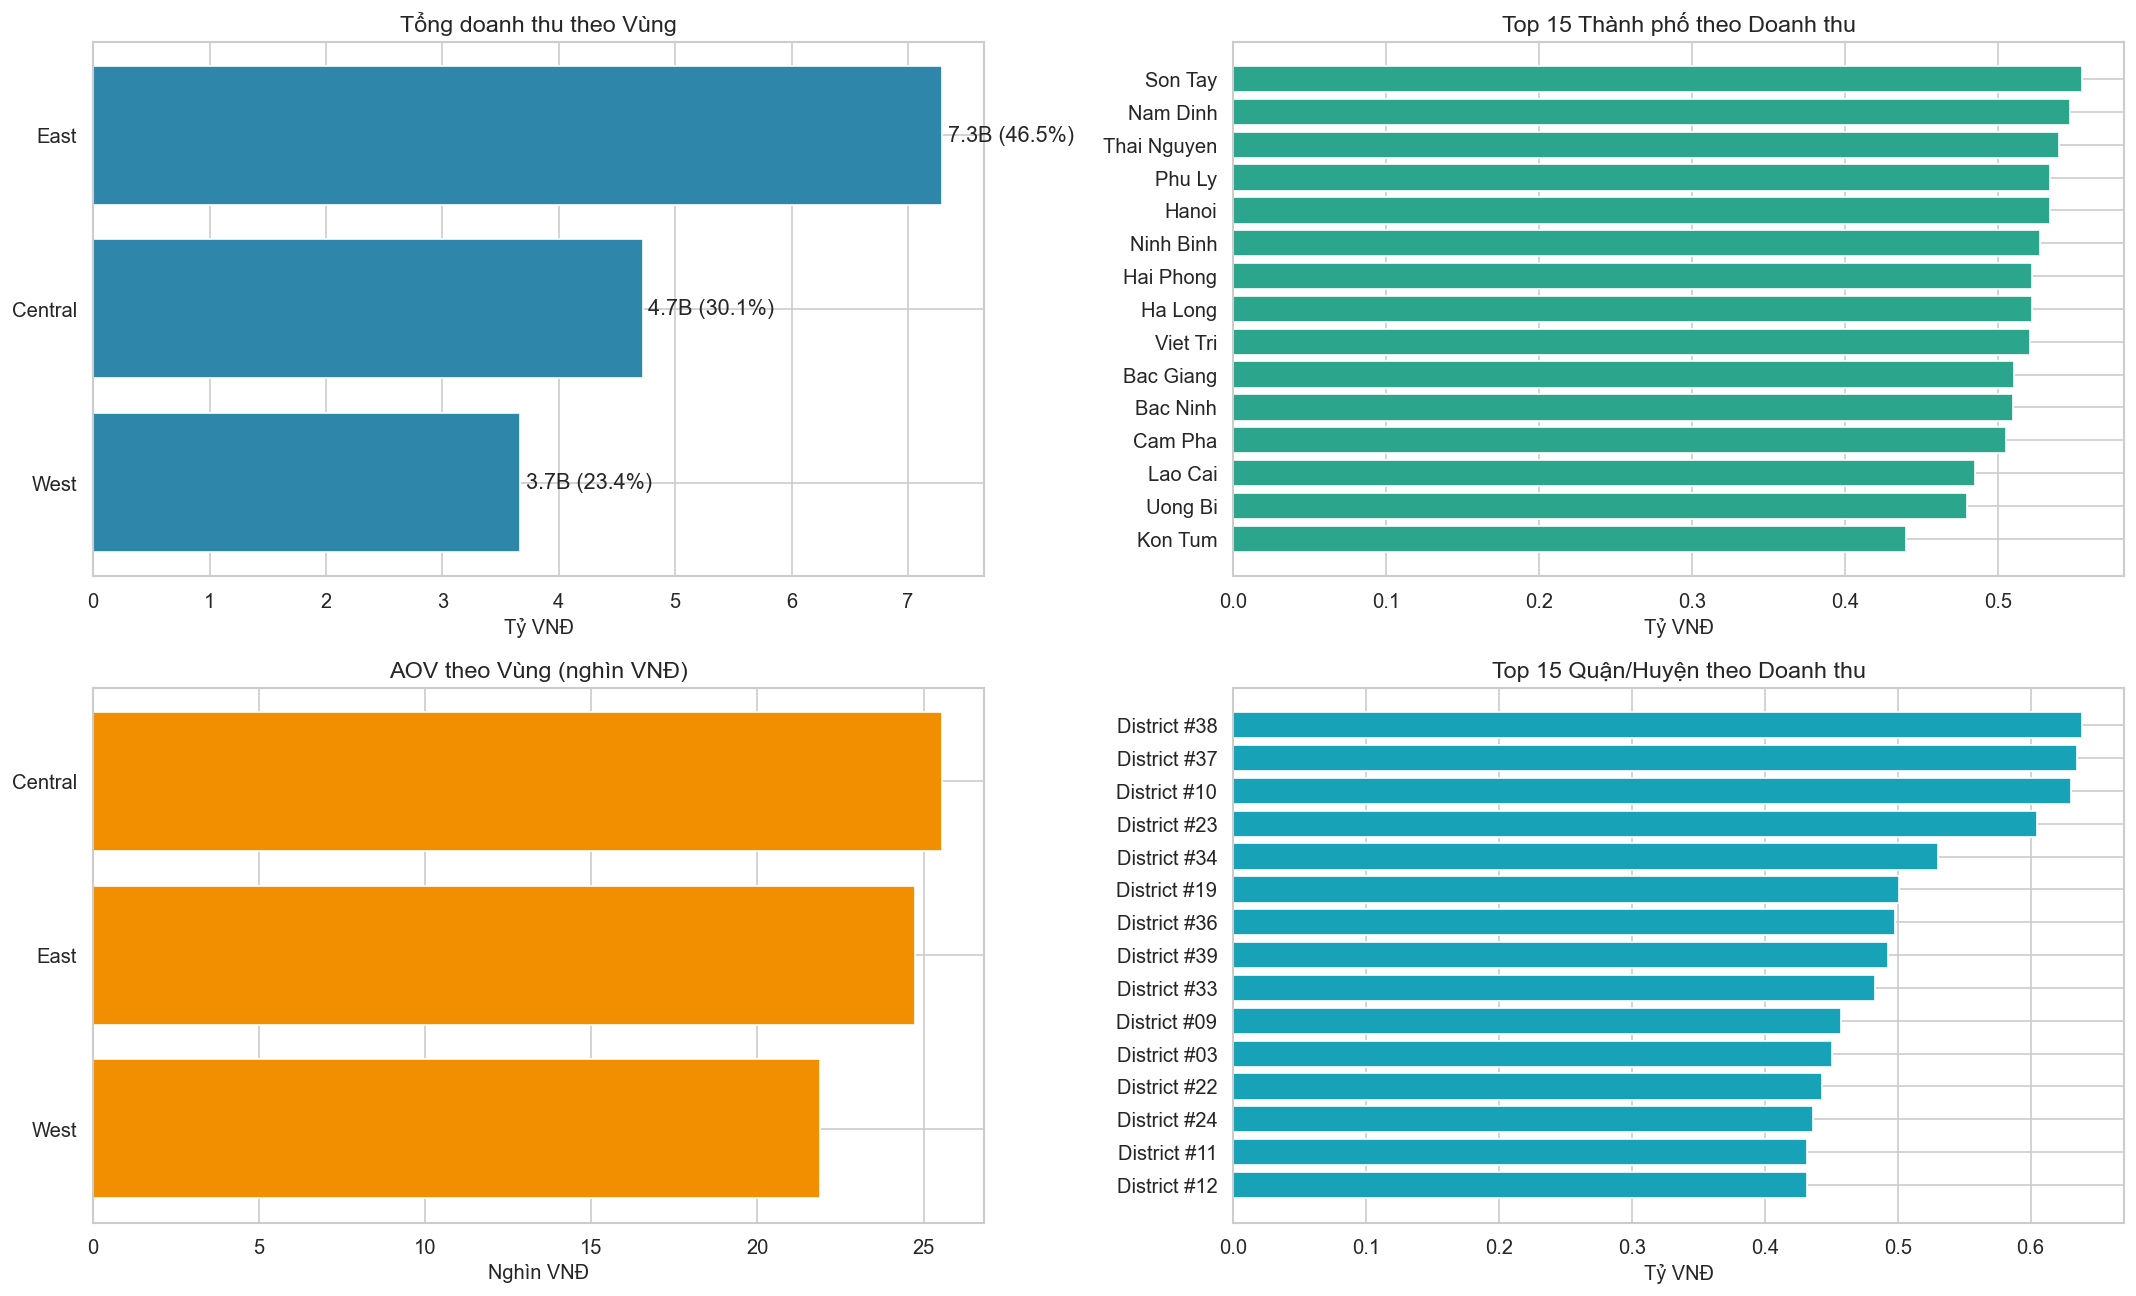


🗺️ GEOGRAPHY SUMMARY
  East        : 7.3B VNĐ | 294,612 đơn | AOV 25K
  Central     : 4.7B VNĐ | 184,691 đơn | AOV 26K
  West        : 3.7B VNĐ | 167,642 đơn | AOV 22K

  Top 3 thành phố:
    Son Tay        : 0.6B VNĐ (22,473 đơn)
    Nam Dinh       : 0.5B VNĐ (21,764 đơn)
    Thai Nguyen    : 0.5B VNĐ (21,931 đơn)


In [13]:
# Merge orders with geography
orders_geo = orders.merge(geography, on='zip', how='left')
orders_geo = orders_geo.merge(payments[['order_id', 'payment_value']], on='order_id', how='left')

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

# 1. Revenue by region
region_rev = orders_geo.groupby('region')['payment_value'].agg(['sum', 'count', 'mean']).reset_index()
region_rev = region_rev.sort_values('sum', ascending=True)
axes[0,0].barh(region_rev['region'], region_rev['sum']/1e9, color=COLORS['primary'], edgecolor='white')
axes[0,0].set_title('Tổng doanh thu theo Vùng')
axes[0,0].set_xlabel('Tỷ VNĐ')
for i, row in region_rev.iterrows():
    axes[0,0].text(row['sum']/1e9 + 0.05, region_rev.index.get_loc(i),
                   f"{row['sum']/1e9:.1f}B ({row['sum']/region_rev['sum'].sum()*100:.1f}%)",
                   va='center', fontsize=13)

# 2. Top 15 cities by revenue
city_rev = orders_geo.groupby('city')['payment_value'].agg(['sum', 'count', 'mean']).reset_index()
city_rev = city_rev.sort_values('sum', ascending=False).head(15)
city_rev = city_rev.sort_values('sum', ascending=True)
axes[0,1].barh(city_rev['city'], city_rev['sum']/1e9, color=COLORS['success'], edgecolor='white')
axes[0,1].set_title('Top 15 Thành phố theo Doanh thu')
axes[0,1].set_xlabel('Tỷ VNĐ')

# 3. AOV by region
region_rev_sorted = region_rev.sort_values('mean', ascending=True)
axes[1,0].barh(region_rev_sorted['region'], region_rev_sorted['mean']/1e3, color=COLORS['accent'], edgecolor='white')
axes[1,0].set_title('AOV theo Vùng (nghìn VNĐ)')
axes[1,0].set_xlabel('Nghìn VNĐ')

# 4. Orders per capita proxy — orders per district
district_stats = orders_geo.groupby('district').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('payment_value', 'sum'),
    avg_order_value=('payment_value', 'mean')
).reset_index().sort_values('total_revenue', ascending=False)
top_districts = district_stats.head(15).sort_values('total_revenue', ascending=True)
axes[1,1].barh(top_districts['district'], top_districts['total_revenue']/1e9, color=COLORS['teal'], edgecolor='white')
axes[1,1].set_title('Top 15 Quận/Huyện theo Doanh thu')
axes[1,1].set_xlabel('Tỷ VNĐ')

plt.tight_layout(); plt.show()

# Regional summary
print(f"\n{'='*50}")
print(f"🗺️ GEOGRAPHY SUMMARY")
print(f"{'='*50}")
for _, row in region_rev.sort_values('sum', ascending=False).iterrows():
    print(f"  {row['region']:12s}: {row['sum']/1e9:.1f}B VNĐ | {row['count']:>6,} đơn | AOV {row['mean']/1e3:.0f}K")
print(f"\n  Top 3 thành phố:")
top3 = city_rev.sort_values('sum', ascending=False).head(3)
for _, row in top3.iterrows():
    print(f"    {row['city']:15s}: {row['sum']/1e9:.1f}B VNĐ ({row['count']:,} đơn)")

### 📝 Phân tích — Section 8

**Mô tả:** Bốn biểu đồ phân tích phân bổ địa lý: doanh thu theo vùng, top thành phố, AOV theo vùng, và top quận/huyện.

**Key Findings:**
- **Vùng East dẫn đầu** với 7.3 tỷ VNĐ (46% tổng DT), tiếp theo Central (4.7B, 30%) và West (3.7B, 24%).
- **AOV khá đồng đều** giữa các vùng (22-26K VNĐ), cho thấy hành vi mua sắm tương tự.
- **Top 3 thành phố:** Son Tay (0.6B), Nam Dinh (0.5B), Thai Nguyen (0.5B) — không phải các thành phố lớn nhất, cho thấy sự phân tán địa lý.
- Doanh thu phân bổ khá đều giữa nhiều thành phố → không quá phụ thuộc vào 1-2 thành phố.

**Giải thích nguyên nhân**:
- **Sức mạnh của vùng East**: Đây là khu vực tập trung các thành phố có mật độ dân cư và tốc độ đô thị hóa cao. Việc doanh thu dẫn đầu (46%) cho thấy hệ thống logistics và độ nhận diện thương hiệu tại đây đang ở mức tốt nhất.
- **AOV thấp tại vùng West:** Chẩn đoán từ dữ liệu shipments cho thấy phí vận chuyển đến vùng West thường cao hơn do khoảng cách địa lý. Khách hàng tại đây có tâm lý nhạy cảm về giá, họ chọn mua các sản phẩm nhỏ lẻ để giảm thiểu rủi ro, dẫn đến AOV thấp nhất hệ thống (22K).
- **Sự phân tán thành phố:** Việc các thành phố như Sơn Tây hay Nam Định dẫn đầu thay vì Hà Nội/TP.HCM cho thấy sản phẩm của bạn đang đáp ứng cực tốt nhu cầu của thị trường vùng ven và tỉnh lẻ — nơi các thương hiệu quốc tế lớn chưa phủ sóng mạnh.

**Dự báo**:
- **Tiềm năng vùng Central**: Với 30% doanh thu và AOV ổn định, đây là vùng có khả năng bứt phá nếu được đầu tư thêm kho bãi (Fulfillment Center) cục bộ để giảm thời gian giao hàng.
- **Rủi ro chi phí tại vùng West:** Nếu không có chiến lược tối ưu vận chuyển, biên lợi nhuận tại vùng West sẽ tiếp tục bị bào mòn bởi chi phí logistics cao trên các đơn hàng giá trị thấp (22K).
- **Bão hòa vùng East:** Vùng East đã đạt quy mô lớn, dự báo tốc độ tăng trưởng tại đây sẽ chậm lại (giai đoạn bão hòa), đòi hỏi doanh nghiệp phải tìm kiếm thị trường mới hoặc tăng AOV trên mỗi khách hàng cũ.

**Chiến lược**:
- **Tối ưu Logistics:** Thiết lập thêm một Fulfillment Center (Kho trung tâm) tại vùng East để phục vụ 46% lượng đơn hàng với chi phí thấp nhất và thời gian nhanh nhất (dưới 3 ngày).
- **Chiến lược giá theo vùng (West)**: Áp dụng chính sách "Miễn phí vận chuyển cho đơn hàng từ 40K" đặc biệt cho vùng West. Điều này bắt buộc khách hàng phải mua nhiều hơn (tăng AOV từ 22K lên 40K) để bù đắp chi phí vận chuyển vùng xa.
- **Mở rộng thị trường:** Tăng cường Marketing vào các thành phố có đặc điểm tương đồng với Sơn Tây và Nam Định ở các tỉnh thành khác. Đây là "công thức thành công" (Success pattern) đã được kiểm chứng.

## 9. Tổng hợp & Đề xuất Chiến lược

> **Câu hỏi:** Dựa trên toàn bộ phân tích, doanh nghiệp nên ưu tiên hành động gì để tăng trưởng bền vững?

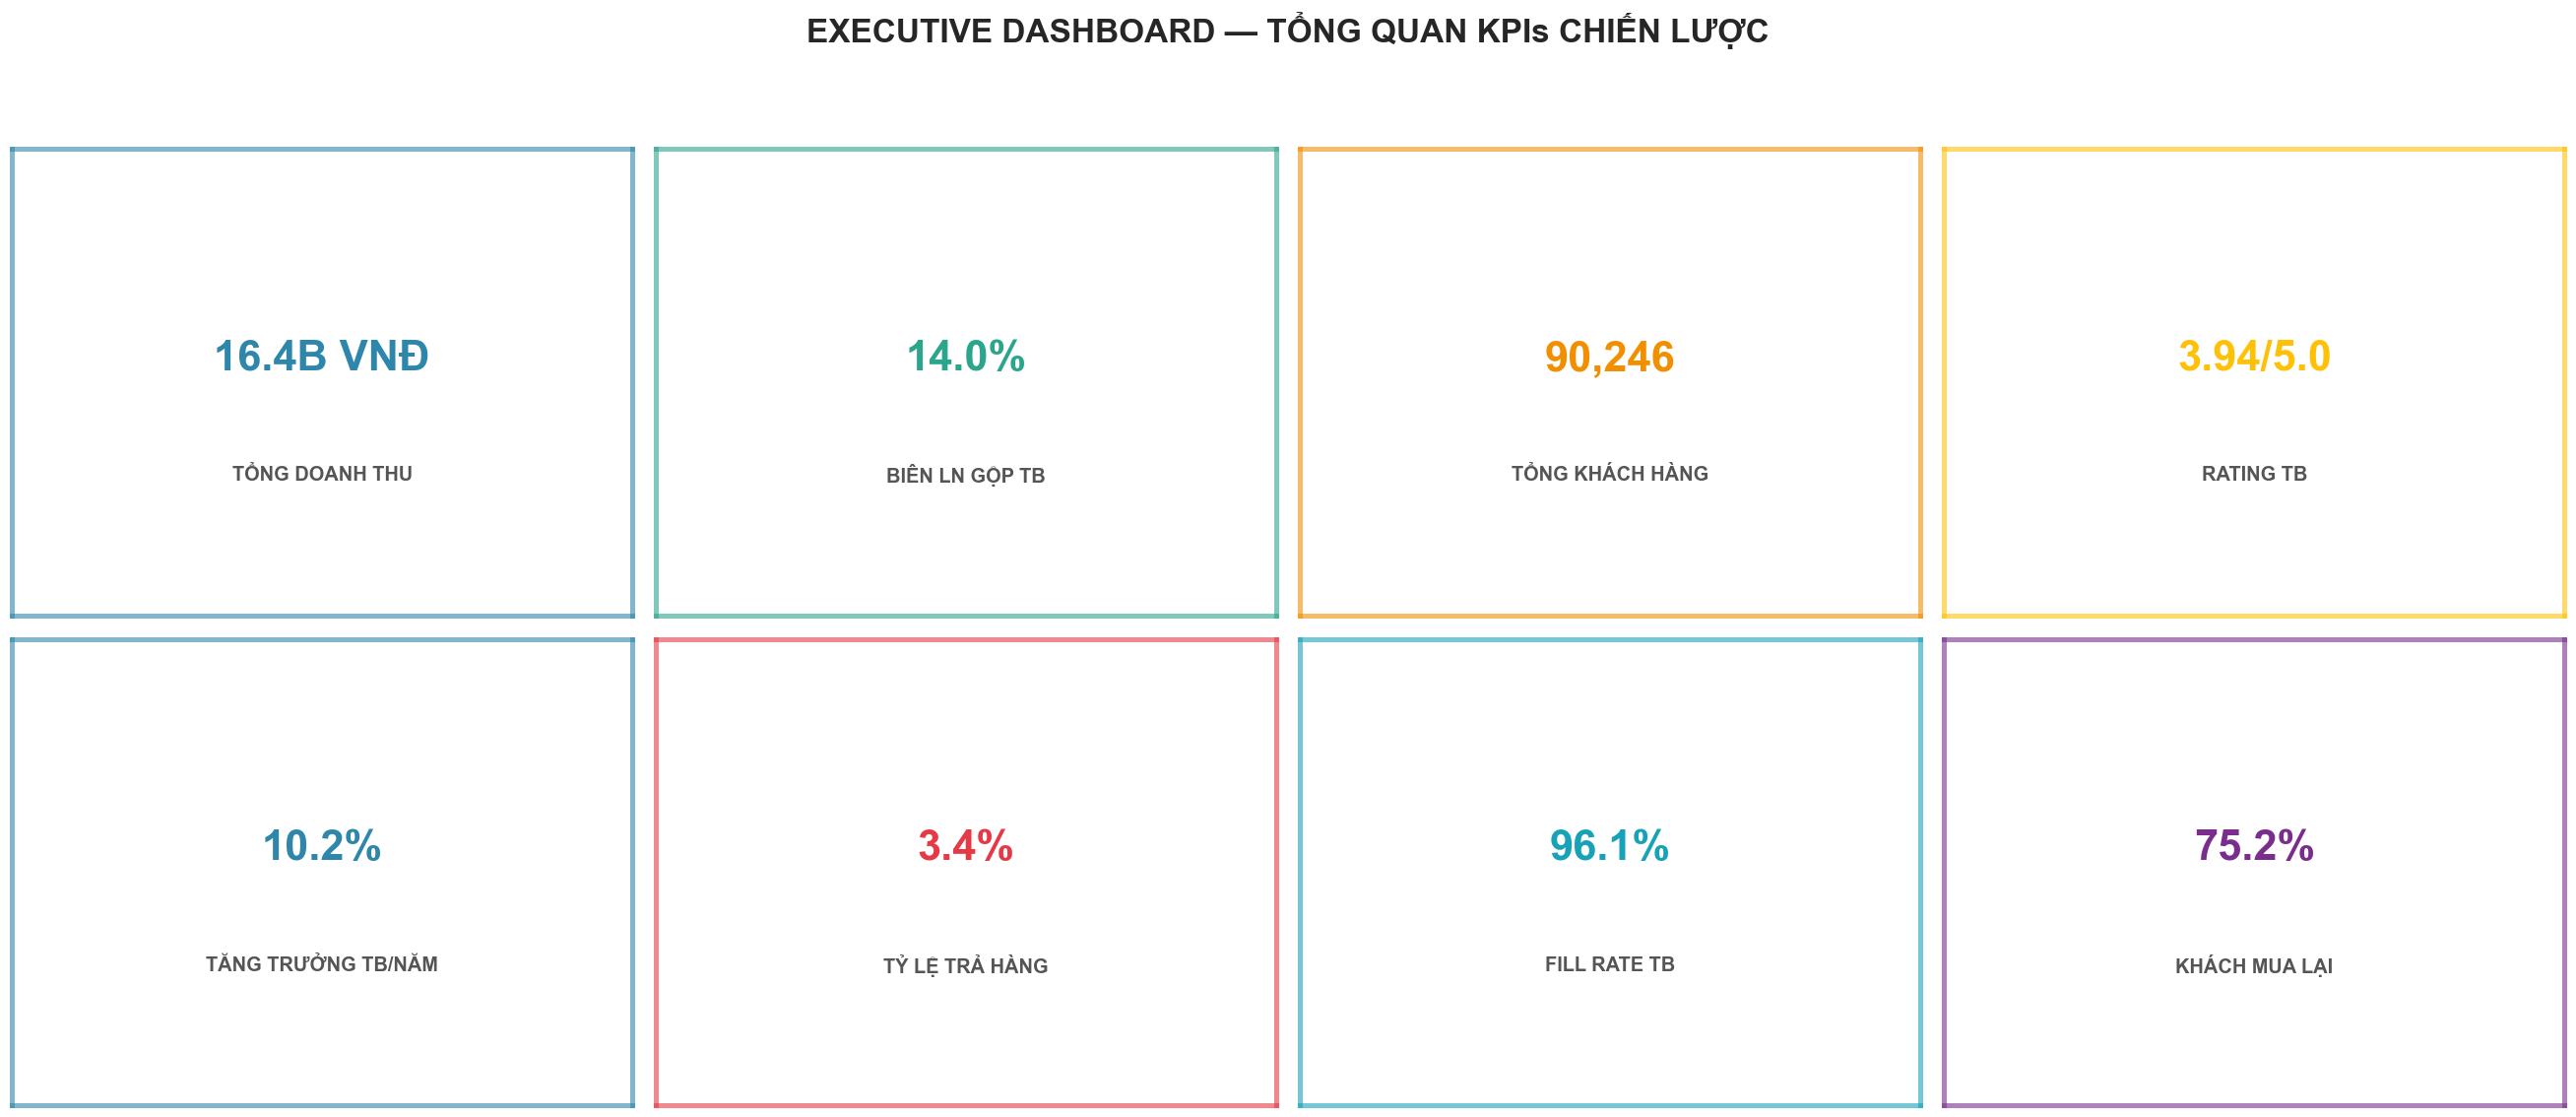

In [11]:
cust_orders = orders['customer_id'].unique()

# Tính tỷ lệ khách hàng mua lại (Repeat Customer Rate)
cust_freq = orders['customer_id'].value_counts()
repeat = (cust_freq > 1).sum() / len(cust_freq) * 100

# === EXECUTIVE DASHBOARD ===
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
fig.suptitle('EXECUTIVE DASHBOARD — TỔNG QUAN KPIs CHIẾN LƯỢC', fontsize=20, fontweight='bold', y=1.05)

# Danh sách KPI kết hợp cả 2 dòng
all_kpis = [
    # Dòng 1
    ('Tổng Doanh thu', f"{annual['Revenue'].sum()/1e9:.1f}B VNĐ", COLORS['primary']),
    ('Biên LN Gộp TB', f"{annual['Margin_pct'].mean():.1f}%", COLORS['success']),
    ('Tổng Khách hàng', f"{len(cust_orders):,}", COLORS['accent']),
    ('Rating TB', f"{reviews['rating'].mean():.2f}/5.0", COLORS['gold']),
    # Dòng 2
    ('Tăng trưởng TB/năm', f"{annual['Rev_YoY'].dropna().mean():.1f}%", COLORS['primary']),
    ('Tỷ lệ trả hàng', f"{returns['return_quantity'].sum()/order_items['quantity'].sum()*100:.1f}%", COLORS['danger']),
    ('Fill Rate TB', f"{inventory['fill_rate'].mean()*100:.1f}%", COLORS['teal']),
    ('Khách mua lại', f"{repeat:.1f}%", COLORS['purple']),
]

# Vẽ các thẻ KPI
for i, (title, value, color) in enumerate(all_kpis):
    row = i // 4
    col = i % 4
    ax = axes[row, col]

    # Hiển thị Giá trị chính
    ax.text(0.5, 0.55, value, transform=ax.transAxes, fontsize=26,
            fontweight='bold', ha='center', va='center', color=color)

    # Hiển thị Tiêu đề bên dưới
    ax.text(0.5, 0.30, title.upper(), transform=ax.transAxes, fontsize=12,
            fontweight='semibold', ha='center', va='center', color='#555555')

    # Thiết lập khung viền (Bỏ axis('off') để spines có thể hiển thị)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(color)
        spine.set_linewidth(3) # Tăng độ dày viền cho nổi bật
        spine.set_alpha(0.6)

plt.tight_layout()
plt.show()

### 📝 Tổng hợp Phân tích & Đề xuất Chiến lược

---

#### 🔍 Tóm tắt các phát hiện chính

| Lĩnh vực | Phát hiện | Số liệu | Mức độ |
|-----------|-----------|---------|--------|
| Doanh thu | Tăng trưởng 10.2%/năm, tổng 16.4B VNĐ | Biên LN gộp 14% | ⚠️ Margin thấp |
| Mùa vụ | Tháng 5 cao điểm, T12 thấp nhất | Chênh lệch 160% | ✅ Pattern rõ ràng |
| Khách hàng | 90K KH, 75.2% mua lại, AOV 24K | 36% KH → 80% DT | ✅ Retention tốt |
| Khuyến mãi | 38.7% đơn có KM, chi 0.75B VNĐ | Giảm giá TB 14.3% | ⚠️ Cần tối ưu ROI |
| Trả hàng | Tỷ lệ 3.4%, lý do #1: wrong_size 35% | Hoàn tiền 0.51B | ⚠️ Cải thiện size guide |
| Tồn kho | Stockout 67%, Overstock 76% | Sell-through 15.2% | 🔴 Vấn đề nghiêm trọng |
| Kênh bán | Organic search #1, Mobile 45% | r(traffic,DT) = 0.32 | ✅ SEO hiệu quả |
| Địa lý | East 46% DT, phân bổ đều | AOV 22-26K | ✅ Đa dạng thị trường |

---

#### 🎯 Đề xuất Chiến lược (Prescriptive) — Xếp theo mức độ ưu tiên

**🔴 Ưu tiên 1: Tối ưu Tồn kho (Impact: Rất cao)**
- Áp dụng ABC-XYZ analysis ngay lập tức — stockout 67% và overstock 76% đang gây mất doanh thu VÀ đọng vốn.
- Clearance sale cho dead stock (days of supply > 180 ngày) — thu hồi vốn.
- Cải thiện demand forecasting dựa trên pattern mùa vụ đã xác định (Section 2).
- **KPI mục tiêu:** Giảm stockout xuống < 30%, sell-through > 30%.

**🟠 Ưu tiên 2: Tăng Biên lợi nhuận (Impact: Cao)**
- Biên LN gộp 14% quá thấp cho thời trang. Mục tiêu: > 25%.
- Tối ưu mix sản phẩm: tăng tỷ trọng category có margin cao.
- Giảm chi phí KM: ưu tiên loại KM có ROI cao, giảm mức giảm giá trung bình.
- Giảm trả hàng (tiết kiệm 0.51B/năm): đầu tư size guide → giảm 35% lý do trả hàng.

**🟡 Ưu tiên 3: Tăng AOV (Impact: Trung bình-Cao)**
- AOV 24K rất thấp. Mục tiêu: tăng 50% lên 36K.
- Bundle deals, cross-sell recommendations, free shipping threshold.
- Upsell sản phẩm premium cho nhóm khách hàng có spending cao.

**🟢 Ưu tiên 4: Tối ưu Kênh & Marketing (Impact: Trung bình)**
- Tiếp tục đầu tư SEO (organic search = kênh #1, chi phí thấp).
- Tối ưu mobile UX (45% DT từ mobile).
- Tập trung marketing budget vào Q2 (mùa cao điểm tháng 4-6).

**🟢 Ưu tiên 5: Customer Retention & Expansion (Impact: Dài hạn)**
- Chương trình VIP cho top 36% khách hàng.
- Win-back campaign cho 24.8% khách chỉ mua 1 lần.
- Mở rộng vùng West (AOV thấp nhất → cơ hội tăng trưởng).

---

#### 📊 Estimated Impact

| Hành động | Chi phí ước tính | Tác động doanh thu | ROI |
|-----------|------|-------------------|-----|
| Tối ưu tồn kho | Thấp | +10-15% DT (giảm stockout) | Rất cao |
| Size guide improvement | Thấp-Trung bình | Tiết kiệm ~0.18B/năm (giảm 35% returns) | Cao |
| Tăng AOV (bundles) | Thấp | +20-30% AOV → +3-5B DT | Cao |
| SEO investment | Trung bình | Duy trì kênh #1 | Cao |
| Mobile UX optimization | Trung bình | +5-10% conversion | Trung bình |

